# 🧬 EXPERIMENTAL FRAMEWORK — HYPERPARAMETER TUNING COMPARISON
## Perbandingan Strategi Tuning: Grid Search vs Random Search vs Bayesian Optimization
## Dataset: Lung Cancer · Breast Cancer · Cervical Cancer

---
| Item | Detail |
|---|---|
| **Dataset** | Lung Cancer · Breast Cancer (Wisconsin) · Cervical Cancer |
| **Model** | XGBoost · RandomForest · SVM · LightGBM |
| **Tuner** | No-Tuning (Baseline) · Grid Search · Random Search · Bayesian Optimization |
| **Target** | Binary Classification (per dataset) |
| **Validasi** | Stratified K-Fold 10 × 10 Runs |

**Pipeline Eksperimen:**
```
Dataset → EDA → Preprocessing (BENAR: fit hanya pada X_train) →
Split 80:20 → imblearn.Pipeline (SMOTE per fold) →
K-Fold 10 × 10 Runs → Tuning (No/Grid/Random/Bayes) →
Evaluasi (F1, AUC, Precision, Recall, Runtime) →
Statistical Test (Wilcoxon + Bonferroni + Effect Size) →
SHAP + Cost-Gain Analysis → Ringkasan Akhir
```
---

## 📦 Bagian 0: Instalasi & Konfigurasi Utama

In [30]:
# ============================================================
# 0.1 INSTALASI LIBRARY
# ============================================================
!pip install xgboost lightgbm scikit-optimize openpyxl shap imbalanced-learn scipy -q
print("✅ Instalasi selesai")

✅ Instalasi selesai


In [31]:
# ============================================================
# 0.2 IMPORT SEMUA LIBRARY
# ============================================================
import warnings, time, os, random, copy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer

# Model selection
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV, cross_validate
)

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score
)

# SMOTE — dibungkus Pipeline agar tidak ada data leakage
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Bayesian Optimization
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# SHAP
import shap

# Statistical tests
from scipy.stats import wilcoxon, friedmanchisquare

import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


In [32]:
# ============================================================
# 0.3 KONFIGURASI UTAMA — SESUAIKAN DI SINI
# ============================================================

# [MODE] 'test' = cepat (pakai N_SAMPLE baris per dataset)
#        'full' = semua data
MODE     = 'full'     # ← ganti ke 'test' untuk prototyping cepat
N_SAMPLE = 500        # ← berlaku hanya saat MODE='test'

# Jumlah runs untuk stabilitas statistik (N≥10 untuk Wilcoxon)
N_RUNS   = 10

# K-Fold CV
CV_FOLDS = 5

# n_iter untuk RandomizedSearchCV & BayesSearchCV
N_ITER_TUNING = 10 if MODE == 'test' else 20

# Output directory
OUTPUT_DIR = '/content'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_out(fname):
    return os.path.join(OUTPUT_DIR, fname)

print(f"⚙️  MODE          = '{MODE}'")
print(f"⚙️  N_RUNS        = {N_RUNS}")
print(f"⚙️  CV_FOLDS      = {CV_FOLDS}")
print(f"⚙️  N_ITER_TUNING = {N_ITER_TUNING}")
print(f"📁 OUTPUT_DIR     = '{OUTPUT_DIR}'")

⚙️  MODE          = 'full'
⚙️  N_RUNS        = 10
⚙️  CV_FOLDS      = 5
⚙️  N_ITER_TUNING = 20
📁 OUTPUT_DIR     = '/content'


## 📂 Bagian 1: Konfigurasi Dataset & Auto-Load

In [33]:
# ============================================================
# 1.1 DEFINISI DATASET (konfigurasi terpusat)
# ============================================================
# Sesuaikan path ke lokasi file CSV Anda.
# Notebook otomatis mencoba Google Drive, lalu path lokal.

DATASET_CONFIG = {
    'Lung Cancer': {
        'gdrive_path' : '/content/drive/MyDrive/Colab Notebooks/survey lung cancer.csv',
        'local_path'  : 'survey_lung_cancer.csv',
        'target'      : 'LUNG_CANCER',
        'sep'         : ',',
    },
    'BreastCancer': {
        'gdrive_path' : '/content/drive/MyDrive/Colab Notebooks/Breast Cancer Winconsin.csv',
        'local_path'  : 'breast_cancer_wisconsin.csv',
        'target'      : 'diagnosis',
        'sep'         : ',',
    },
    'CervicalCancer': {
        'gdrive_path' : '/content/drive/MyDrive/Colab Notebooks/risk_factors_cervical_cancer.csv',
        'local_path'  : 'cervical_cancer.csv',
        'target'      : 'Biopsy',
        'sep'         : ',',
    },
}

MODEL_NAMES  = ['XGBoost', 'RandomForest', 'SVM', 'LightGBM']
TUNER_NAMES  = ['No-Tuning', 'Grid', 'Random', 'Bayes']

print("✅ Konfigurasi dataset:")
for ds, cfg in DATASET_CONFIG.items():
    print(f"   • {ds:<20} target='{cfg['target']}'")

✅ Konfigurasi dataset:
   • Lung Cancer          target='LUNG_CANCER'
   • BreastCancer         target='diagnosis'
   • CervicalCancer       target='Biopsy'


In [34]:
# ============================================================
# 1.2 AUTO-LOAD DATASET (Google Drive → lokal → upload manual)
# ============================================================
try:
    from google.colab import drive, files as colab_files
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
    print("🔵 Google Colab terdeteksi — Drive terhubung")
except ImportError:
    IN_COLAB = False
    print("🟡 Bukan Colab — mode lokal/Kaggle")

def resolve_path(cfg):
    if IN_COLAB and os.path.exists(cfg['gdrive_path']):
        return cfg['gdrive_path']
    if os.path.exists(cfg['local_path']):
        return cfg['local_path']
    return None

print()
for ds, cfg in DATASET_CONFIG.items():
    p = resolve_path(cfg)
    if p:
        print(f"   ✅ {ds:<20} → {p}")
    else:
        print(f"   ⚠️  {ds:<20} → FILE TIDAK DITEMUKAN (update path di 1.1)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔵 Google Colab terdeteksi — Drive terhubung

   ✅ Lung Cancer          → /content/drive/MyDrive/Colab Notebooks/survey lung cancer.csv
   ✅ BreastCancer         → /content/drive/MyDrive/Colab Notebooks/Breast Cancer Winconsin.csv
   ✅ CervicalCancer       → /content/drive/MyDrive/Colab Notebooks/risk_factors_cervical_cancer.csv


In [35]:
# ============================================================
# 1.3 LOAD + SAMPLING SEMUA DATASET
# ============================================================
datasets_raw = {}

for ds_name, cfg in DATASET_CONFIG.items():
    path = resolve_path(cfg)
    if path is None:
        print(f"⚠️  {ds_name}: skip (file tidak ditemukan)")
        continue
    try:
        df = pd.read_csv(path, sep=cfg['sep'], na_values=['?','NA','null',''])
        df = df.drop_duplicates().reset_index(drop=True)

        if MODE == 'test':
            n_take = min(N_SAMPLE, len(df))
            df = df.sample(n=n_take, random_state=SEED).reset_index(drop=True)

        datasets_raw[ds_name] = df
        tgt = cfg['target']
        vc  = df[tgt].value_counts()
        print(f"✅ {ds_name:<20} shape={df.shape}  target='{tgt}'")
        print(f"   Distribusi: {dict(vc)}")
    except Exception as e:
        print(f"❌ {ds_name}: Error — {e}")

print(f"\n📦 Dataset berhasil dimuat: {list(datasets_raw.keys())}")

✅ Lung Cancer          shape=(276, 16)  target='LUNG_CANCER'
   Distribusi: {'YES': np.int64(238), 'NO': np.int64(38)}
✅ BreastCancer         shape=(569, 33)  target='diagnosis'
   Distribusi: {'B': np.int64(357), 'M': np.int64(212)}
✅ CervicalCancer       shape=(835, 36)  target='Biopsy'
   Distribusi: {0: np.int64(781), 1: np.int64(54)}

📦 Dataset berhasil dimuat: ['Lung Cancer', 'BreastCancer', 'CervicalCancer']


## 🔍 Bagian 2: Exploratory Data Analysis (EDA)

In [36]:
# ============================================================
# 2.1 RINGKASAN STATISTIK PER DATASET
# ============================================================
for ds_name, df in datasets_raw.items():
    tgt = DATASET_CONFIG[ds_name]['target']
    print(f"\n{'='*60}")
    print(f"DATASET: {ds_name}")
    print(f"{'='*60}")
    print(f"  Shape        : {df.shape}")
    print(f"  Missing (%)  : {df.isnull().mean().mean()*100:.2f}%")
    print(f"  Duplikat     : {df.duplicated().sum()}")

    y = df[tgt]
    if y.dtype == 'object':
        vc = y.value_counts()
    else:
        vc = y.value_counts()

    classes = vc.index.tolist()
    counts  = vc.values.tolist()
    ratio   = max(counts) / min(counts)
    print(f"  Kelas        : {dict(zip(classes, counts))}")
    print(f"  Imbalance    : {ratio:.2f}:1 → {'IMBALANCED ⚠️' if ratio > 1.5 else 'BALANCED ✅'}")
    print(f"  Tipe kolom   :")
    print(f"    Numerik    : {df.select_dtypes(include='number').shape[1]}")
    print(f"    Kategorikal: {df.select_dtypes(include='object').shape[1]}")


DATASET: Lung Cancer
  Shape        : (276, 16)
  Missing (%)  : 0.00%
  Duplikat     : 0
  Kelas        : {'YES': 238, 'NO': 38}
  Imbalance    : 6.26:1 → IMBALANCED ⚠️
  Tipe kolom   :
    Numerik    : 14
    Kategorikal: 2

DATASET: BreastCancer
  Shape        : (569, 33)
  Missing (%)  : 3.03%
  Duplikat     : 0
  Kelas        : {'B': 357, 'M': 212}
  Imbalance    : 1.68:1 → IMBALANCED ⚠️
  Tipe kolom   :
    Numerik    : 32
    Kategorikal: 1

DATASET: CervicalCancer
  Shape        : (835, 36)
  Missing (%)  : 11.59%
  Duplikat     : 0
  Kelas        : {0: 781, 1: 54}
  Imbalance    : 14.46:1 → IMBALANCED ⚠️
  Tipe kolom   :
    Numerik    : 36
    Kategorikal: 0


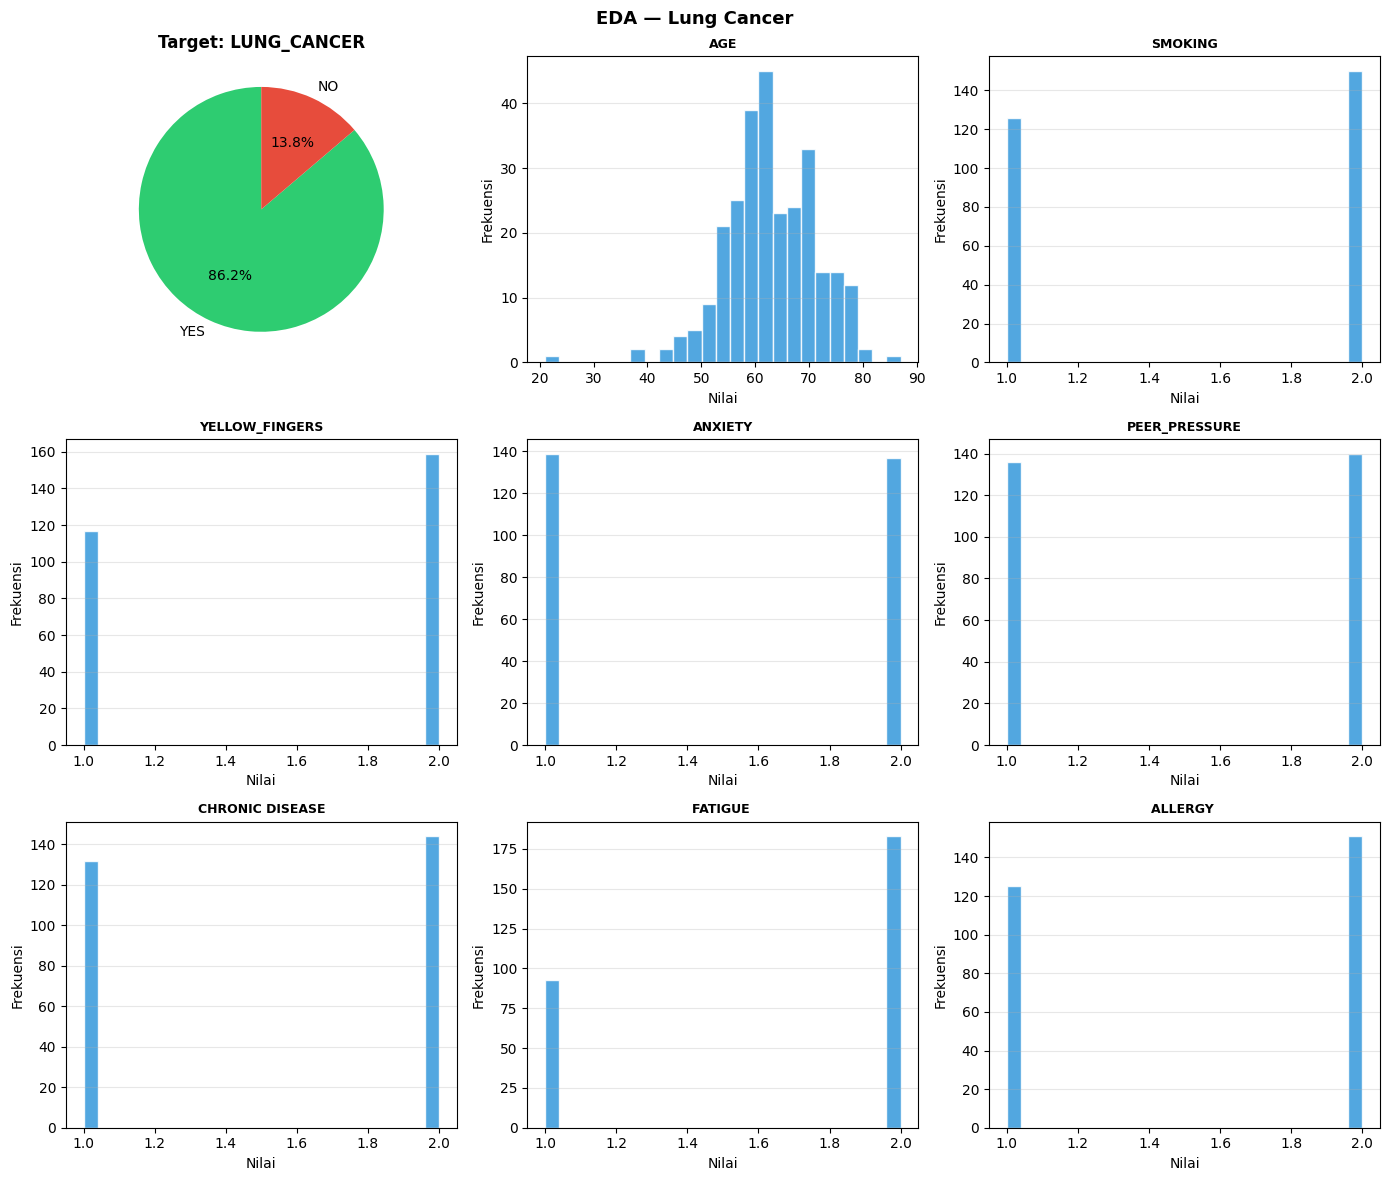

✅ EDA plot tersimpan: eda_Lung_Cancer.png


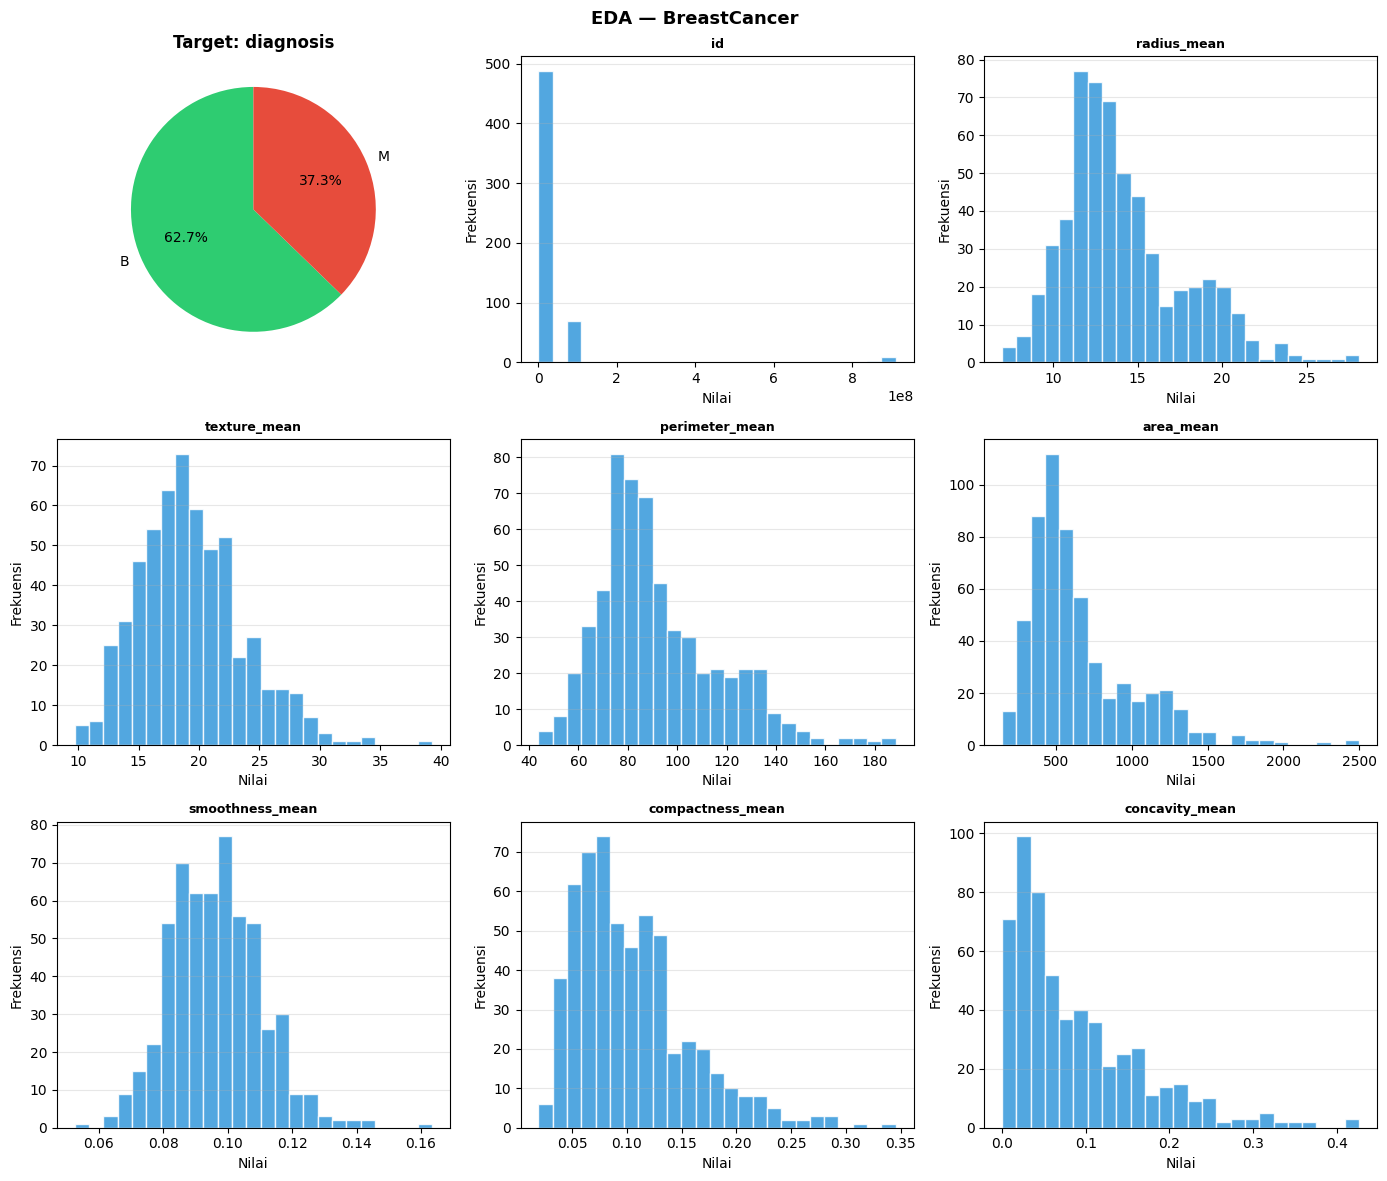

✅ EDA plot tersimpan: eda_BreastCancer.png


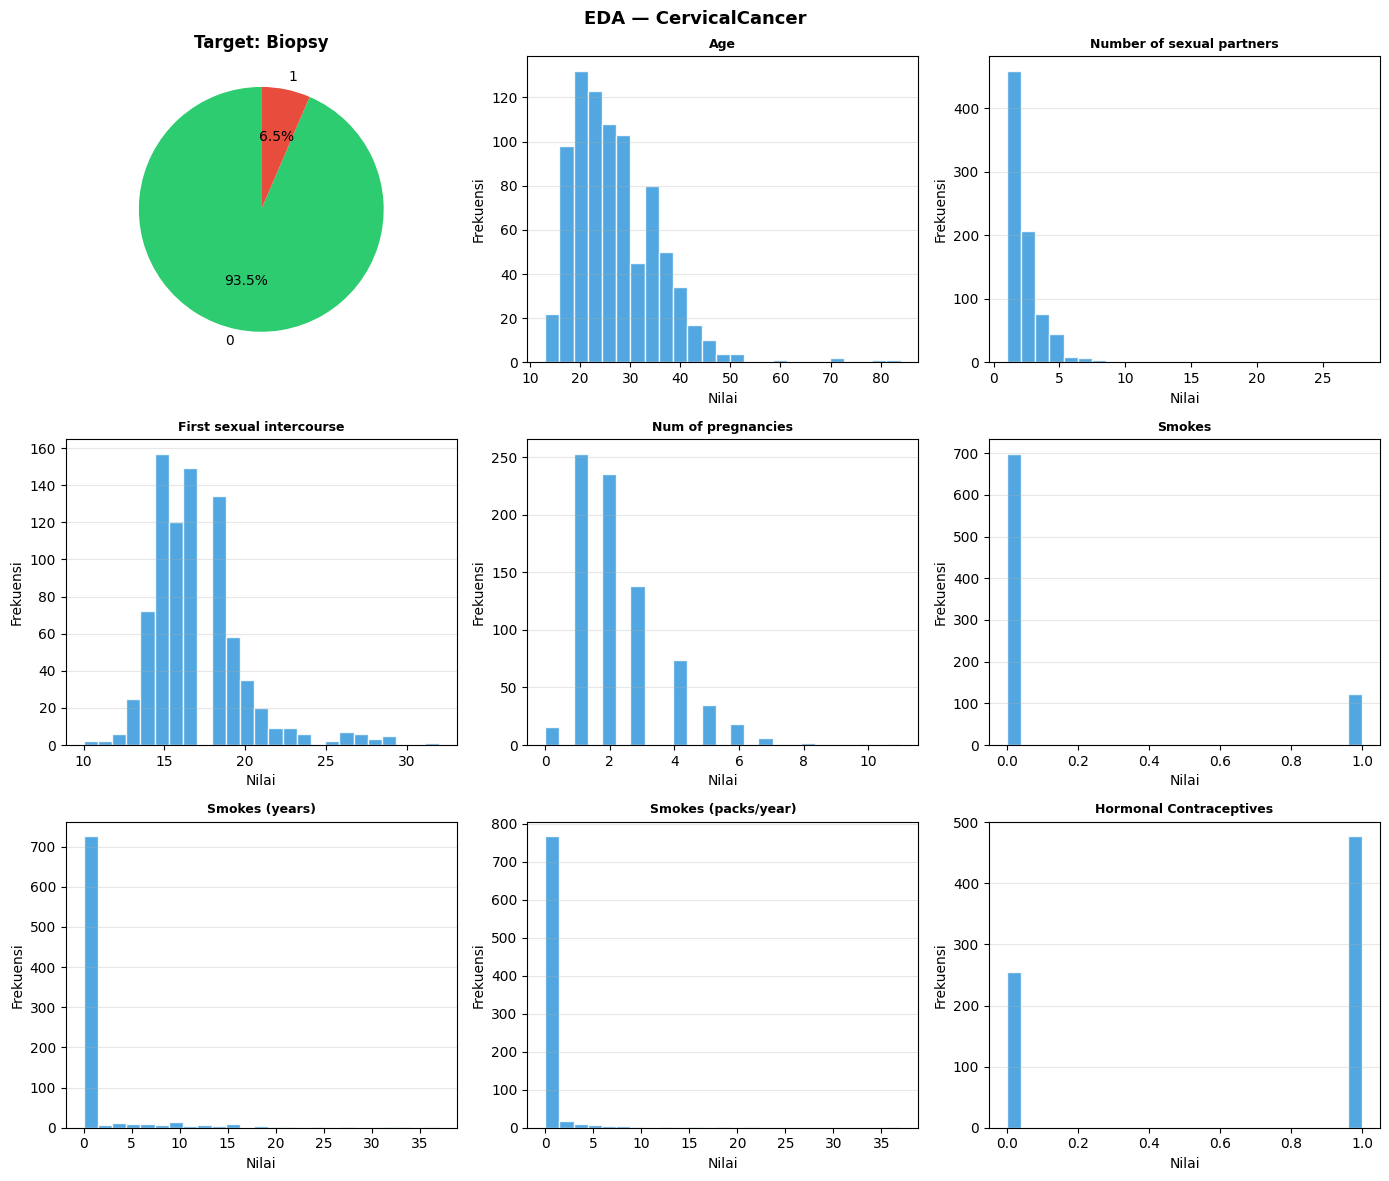

✅ EDA plot tersimpan: eda_CervicalCancer.png


In [37]:
# ============================================================
# 2.2 VISUALISASI EDA — DISTRIBUSI TARGET + FITUR NUMERIK
# ============================================================
for ds_name, df in datasets_raw.items():
    tgt = DATASET_CONFIG[ds_name]['target']
    num_cols = df.drop(columns=[tgt]).select_dtypes(include='number').columns.tolist()[:8]
    n_plots  = 1 + len(num_cols)
    ncols    = 3
    nrows    = (n_plots + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
    axes = axes.flatten()
    fig.suptitle(f'EDA — {ds_name}', fontsize=13, fontweight='bold')

    # Plot distribusi target
    vc     = df[tgt].value_counts()
    colors = ['#2ecc71','#e74c3c','#3498db','#f39c12']
    axes[0].pie(vc.values, labels=[str(x) for x in vc.index],
                colors=colors[:len(vc)], autopct='%1.1f%%', startangle=90)
    axes[0].set_title(f'Target: {tgt}', fontweight='bold')

    # Plot fitur numerik
    for i, col in enumerate(num_cols, 1):
        axes[i].hist(df[col].dropna(), bins=25, color='#3498db',
                     edgecolor='white', alpha=0.85)
        axes[i].set_title(col[:30], fontsize=9, fontweight='bold')
        axes[i].set_xlabel('Nilai'); axes[i].set_ylabel('Frekuensi')
        axes[i].grid(axis='y', alpha=0.3)

    for j in range(n_plots, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_out(f'eda_{ds_name.replace(" ","_")}.png'),
                dpi=130, bbox_inches='tight')
    plt.show()
    print(f"✅ EDA plot tersimpan: eda_{ds_name.replace(' ','_')}.png")

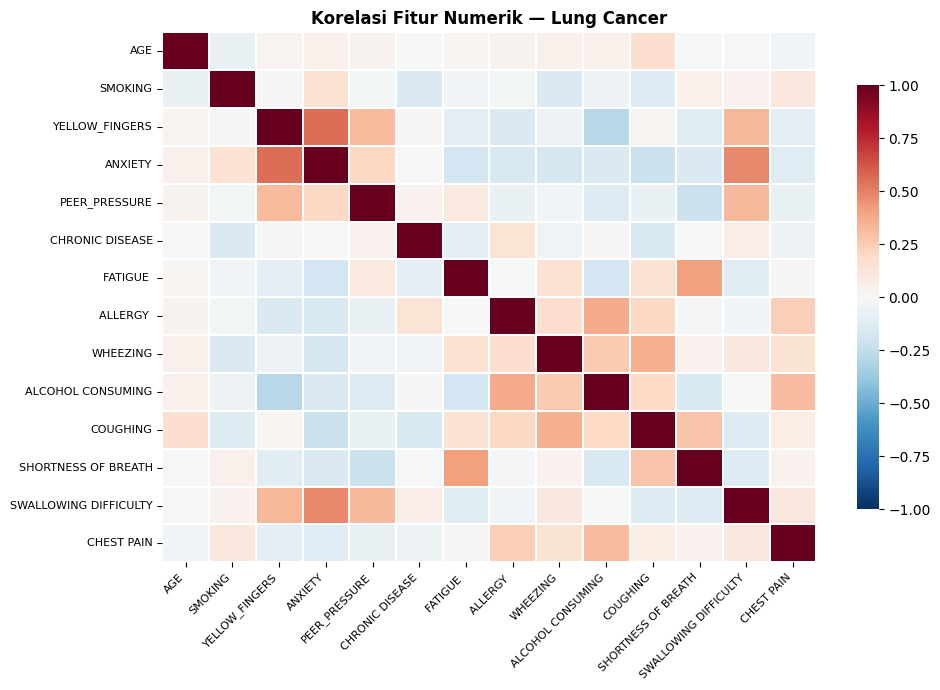

✅ Lung Cancer: tidak ada pasangan korelasi >0.85


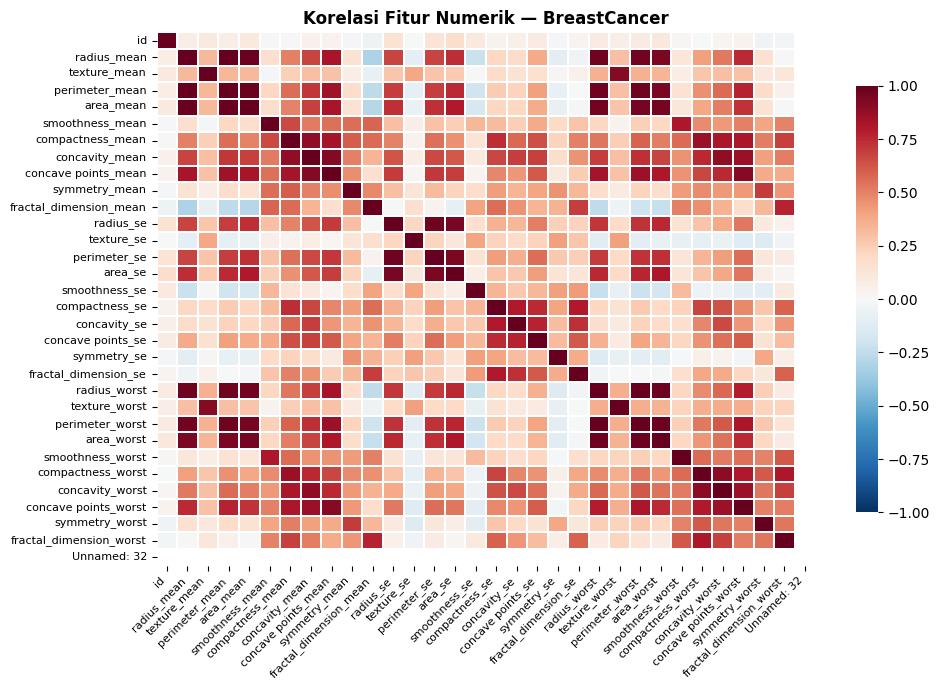

⚠️  BreastCancer — Pasangan korelasi >0.85 (kandidat redundan):
   radius_mean ↔ perimeter_mean : 0.998
   radius_mean ↔ area_mean : 0.987
   radius_mean ↔ radius_worst : 0.97
   radius_mean ↔ perimeter_worst : 0.965
   radius_mean ↔ area_worst : 0.941
   texture_mean ↔ texture_worst : 0.912
   perimeter_mean ↔ area_mean : 0.987
   perimeter_mean ↔ concave points_mean : 0.851
   perimeter_mean ↔ radius_worst : 0.969
   perimeter_mean ↔ perimeter_worst : 0.97
   perimeter_mean ↔ area_worst : 0.942
   area_mean ↔ radius_worst : 0.963
   area_mean ↔ perimeter_worst : 0.959
   area_mean ↔ area_worst : 0.959
   compactness_mean ↔ concavity_mean : 0.883
   compactness_mean ↔ compactness_worst : 0.866
   concavity_mean ↔ concave points_mean : 0.921
   concavity_mean ↔ concavity_worst : 0.884
   concavity_mean ↔ concave points_worst : 0.861
   concave points_mean ↔ perimeter_worst : 0.856
   concave points_mean ↔ concave points_worst : 0.91
   radius_se ↔ perimeter_se : 0.973
   radius_se ↔ ar

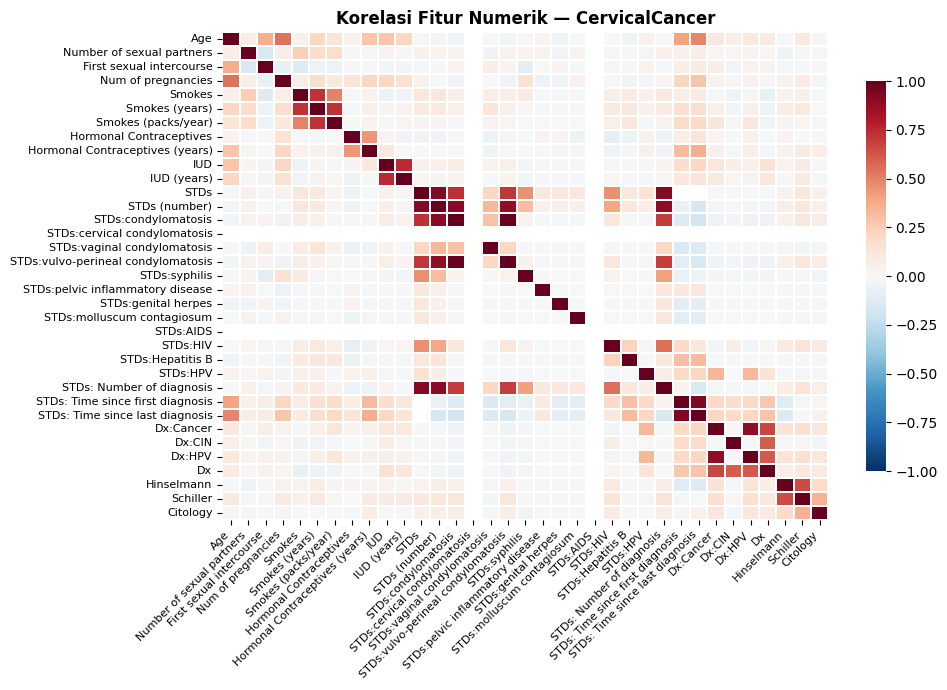

⚠️  CervicalCancer — Pasangan korelasi >0.85 (kandidat redundan):
   STDs ↔ STDs (number) : 0.918
   STDs ↔ STDs: Number of diagnosis : 0.906
   STDs (number) ↔ STDs:condylomatosis : 0.899
   STDs (number) ↔ STDs:vulvo-perineal condylomatosis : 0.891
   STDs (number) ↔ STDs: Number of diagnosis : 0.897
   STDs:condylomatosis ↔ STDs:vulvo-perineal condylomatosis : 0.988
   STDs: Time since first diagnosis ↔ STDs: Time since last diagnosis : 0.931
   Dx:Cancer ↔ Dx:HPV : 0.886


In [38]:
# ============================================================
# 2.3 HEATMAP KORELASI ANTAR FITUR NUMERIK
# ============================================================
for ds_name, df in datasets_raw.items():
    tgt      = DATASET_CONFIG[ds_name]['target']
    num_cols = df.drop(columns=[tgt]).select_dtypes(include='number').columns.tolist()

    if len(num_cols) < 2:
        print(f"⚠️  {ds_name}: tidak cukup fitur numerik untuk heatmap")
        continue

    corr = df[num_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(corr, annot=len(num_cols)<=12, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.3, ax=ax, cbar_kws={'shrink':0.8})
    ax.set_title(f'Korelasi Fitur Numerik — {ds_name}', fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.savefig(save_out(f'korrelasi_{ds_name.replace(" ","_")}.png'),
                dpi=130, bbox_inches='tight')
    plt.show()

    # Flag high correlation
    high = [(corr.columns[i], corr.columns[j], round(corr.iloc[i,j],3))
            for i in range(len(corr.columns))
            for j in range(i+1, len(corr.columns))
            if abs(corr.iloc[i,j]) > 0.85]
    if high:
        print(f"⚠️  {ds_name} — Pasangan korelasi >0.85 (kandidat redundan):")
        for f1,f2,r in high: print(f"   {f1} ↔ {f2} : {r}")
    else:
        print(f"✅ {ds_name}: tidak ada pasangan korelasi >0.85")

## ⚙️ Bagian 3: Preprocessing Data (Pipeline-safe, No Leakage)

In [39]:
# ============================================================
# 3.1 FUNGSI PREPROCESSING (BENAR: fit hanya pada X_train)
# ============================================================
# METODOLOGI KRITIS:
#   preprocess_data() HANYA memisahkan X dan y + encode target.
#   Scaling & imputation dilakukan di dalam imblearn.Pipeline
#   agar hanya fit pada training fold — mencegah data leakage.

def encode_target(y_series):
    """Encode target ke 0/1. Return (y_encoded, label_mapping)."""
    if y_series.dtype == 'object':
        le = LabelEncoder()
        y_enc = le.fit_transform(y_series)
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        return y_enc, mapping
    return y_series.values, None

def prepare_xy(df, target_col):
    """
    Pisahkan X dan y. Encode target jika perlu.
    LabelEncoder pada fitur kategorikal di-fit di dalam Pipeline per fold.
    """
    if 'id' in df.columns:
        df = df.drop(columns=['id'])
    X = df.drop(columns=[target_col]).copy()
    y, mapping = encode_target(df[target_col])
    return X, y, mapping

def get_feature_names(preprocessor, num_cols, cat_cols):
    """Ambil nama fitur setelah transformasi ColumnTransformer."""
    feat_names = list(num_cols)
    if cat_cols and 'cat' in preprocessor.named_transformers_:
        ohe = preprocessor.named_transformers_['cat']['ohe']
        feat_names += list(ohe.get_feature_names_out(cat_cols))
    return feat_names

def build_preprocessor(X_df):
    """
    Buat ColumnTransformer (belum di-fit).
    Fitting dilakukan di dalam Pipeline per fold — BUKAN di sini.
    """
    num_cols = X_df.select_dtypes(include=['int64','float64']).columns.tolist()
    cat_cols = X_df.select_dtypes(include=['object']).columns.tolist()

    num_pipe = SkPipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
    ])
    cat_pipe = SkPipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    steps = []
    if num_cols: steps.append(('num', num_pipe, num_cols))
    if cat_cols: steps.append(('cat', cat_pipe, cat_cols))

    pre = ColumnTransformer(steps, remainder='drop')
    return pre, num_cols, cat_cols

print("✅ Fungsi preprocessing (no-leakage) siap")

✅ Fungsi preprocessing (no-leakage) siap


In [40]:
# ============================================================
# 3.2 SIAPKAN X, y UNTUK SEMUA DATASET
# ============================================================
datasets_xy = {}

for ds_name, df in datasets_raw.items():
    tgt = DATASET_CONFIG[ds_name]['target']
    X, y, mapping = prepare_xy(df, tgt)
    pre, num_cols, cat_cols = build_preprocessor(X)

    datasets_xy[ds_name] = {
        'X': X, 'y': y,
        'target': tgt,
        'mapping': mapping,
        'preprocessor': pre,
        'num_cols': num_cols,
        'cat_cols': cat_cols,
    }

    classes, counts = np.unique(y, return_counts=True)
    print(f"✅ {ds_name:<20} X={X.shape}  y={dict(zip(classes.tolist(),counts.tolist()))}")
    if mapping:
        print(f"   Mapping target: {mapping}")

✅ Lung Cancer          X=(276, 15)  y={0: 38, 1: 238}
   Mapping target: {'NO': np.int64(0), 'YES': np.int64(1)}
✅ BreastCancer         X=(569, 31)  y={0: 357, 1: 212}
   Mapping target: {'B': np.int64(0), 'M': np.int64(1)}
✅ CervicalCancer       X=(835, 35)  y={0: 781, 1: 54}


## ✂️ Bagian 4: Split Data & imblearn.Pipeline (SMOTE per Fold)

In [41]:
# ============================================================
# 4.1 SPLIT 80:20 STRATIFIED (PER DATASET)
# ============================================================
datasets_split = {}

for ds_name, data in datasets_xy.items():
    X, y = data['X'], data['y']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    datasets_split[ds_name] = {
        **data,
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
    }

    print(f"✅ {ds_name:<20} Train={len(y_train):,}  Test={len(y_test):,}")
    for split, yy in [('Train', y_train), ('Test', y_test)]:
        u, c = np.unique(yy, return_counts=True)
        dist = ' | '.join([f"cls{v}={cnt}({cnt/len(yy)*100:.1f}%)" for v,cnt in zip(u,c)])
        print(f"   {split}: {dist}")

✅ Lung Cancer          Train=220  Test=56
   Train: cls0=30(13.6%) | cls1=190(86.4%)
   Test: cls0=8(14.3%) | cls1=48(85.7%)
✅ BreastCancer         Train=455  Test=114
   Train: cls0=285(62.6%) | cls1=170(37.4%)
   Test: cls0=72(63.2%) | cls1=42(36.8%)
✅ CervicalCancer       Train=668  Test=167
   Train: cls0=625(93.6%) | cls1=43(6.4%)
   Test: cls0=156(93.4%) | cls1=11(6.6%)


In [42]:
# ============================================================
# 4.2 FACTORY: imblearn.Pipeline (Preprocessor + SMOTE + Model)
# ============================================================
# METODOLOGI KRITIS:
#   SMOTE dibungkus dalam ImbPipeline.
#   Saat cross_validate dipanggil:
#     → Per fold: Pipeline fit pada training fold saja
#     → SMOTE hanya dijalankan pada training fold
#     → Validation fold TIDAK pernah di-SMOTE
#   → Tidak ada data leakage synthetic samples ✅

def make_pipeline(preprocessor, model, smote_k=5):
    """Buat ImbPipeline: preprocessor → SMOTE → classifier."""
    return ImbPipeline([
        ('pre',   copy.deepcopy(preprocessor)),
        ('smote', SMOTE(random_state=SEED, k_neighbors=smote_k)),
        ('clf',   copy.deepcopy(model)),
    ])

def build_model(model_name, seed=SEED):
    if model_name == 'XGBoost':
        return XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                             random_state=seed, use_label_encoder=False, verbosity=0)
    elif model_name == 'RandomForest':
        return RandomForestClassifier(random_state=seed, n_jobs=-1)
    elif model_name == 'SVM':
        return SVC(probability=True, random_state=seed)
    elif model_name == 'LightGBM':
        return LGBMClassifier(random_state=seed, verbose=-1)
    raise ValueError(f'Unknown model: {model_name}')

print("✅ Pipeline factory siap")
print("   Flow: X_raw → Preprocessor (fit train only) → SMOTE (train fold only) → Classifier")

✅ Pipeline factory siap
   Flow: X_raw → Preprocessor (fit train only) → SMOTE (train fold only) → Classifier


In [43]:
# ============================================================
# 4.3 SEARCH SPACES UNTUK SEMUA TUNER
# ============================================================
# Budget evaluasi diseimbangkan: Grid ≈ Random ≈ Bayes (≈20 kombinasi)

PARAM_GRID = {
    'XGBoost'     : {'clf__learning_rate':[0.01,0.05,0.1],
                     'clf__max_depth':[3,5,7],
                     'clf__n_estimators':[100,200],
                     'clf__subsample':[0.8,1.0]},
    'RandomForest': {'clf__n_estimators':[100,200],
                     'clf__max_depth':[None,5,10],
                     'clf__min_samples_split':[2,5],
                     'clf__max_features':['sqrt','log2']},
    'SVM'         : {'clf__C':[0.1,1,10],
                     'clf__kernel':['rbf','linear'],
                     'clf__gamma':['scale','auto']},
    'LightGBM'    : {'clf__learning_rate':[0.01,0.05,0.1],
                     'clf__n_estimators':[100,200],
                     'clf__max_depth':[3,5,7],
                     'clf__num_leaves':[31,63]},
}

PARAM_RANDOM = {
    'XGBoost'     : {'clf__learning_rate':[0.01,0.05,0.1,0.2],
                     'clf__max_depth':[3,5,7,9],
                     'clf__n_estimators':[50,100,200,300],
                     'clf__subsample':[0.6,0.8,1.0]},
    'RandomForest': {'clf__n_estimators':[50,100,200,300],
                     'clf__max_depth':[None,5,10,20],
                     'clf__min_samples_split':[2,5,10],
                     'clf__max_features':['sqrt','log2']},
    'SVM'         : {'clf__C':[0.01,0.1,1,10,100],
                     'clf__kernel':['rbf','linear'],
                     'clf__gamma':['scale','auto']},
    'LightGBM'    : {'clf__learning_rate':[0.01,0.05,0.1,0.2],
                     'clf__n_estimators':[50,100,200,300],
                     'clf__max_depth':[3,5,7,9],
                     'clf__num_leaves':[15,31,63,127]},
}

PARAM_BAYES = {
    'XGBoost'     : {'clf__learning_rate':Real(0.01,0.3),
                     'clf__max_depth':Integer(3,10),
                     'clf__n_estimators':Integer(50,300),
                     'clf__subsample':Real(0.5,1.0)},
    'RandomForest': {'clf__n_estimators':Integer(50,300),
                     'clf__max_depth':Integer(3,20),
                     'clf__min_samples_split':Integer(2,10),
                     'clf__max_features':Categorical(['sqrt','log2'])},
    'SVM'         : {'clf__C':Real(0.01,100.0,prior='log-uniform'),
                     'clf__kernel':Categorical(['rbf','linear']),
                     'clf__gamma':Categorical(['scale','auto'])},
    'LightGBM'    : {'clf__learning_rate':Real(0.01,0.3),
                     'clf__n_estimators':Integer(50,300),
                     'clf__max_depth':Integer(3,10),
                     'clf__num_leaves':Integer(15,127)},
}

print("✅ Search spaces siap (prefix clf__ untuk Pipeline compatibility)")
for mn in MODEL_NAMES:
    from functools import reduce
    import operator
    g = reduce(operator.mul, [len(v) for v in PARAM_GRID[mn].values()], 1)
    print(f"   {mn:<14} Grid≈{g} kombinasi | Random/Bayes={N_ITER_TUNING} iter (seimbang)")

✅ Search spaces siap (prefix clf__ untuk Pipeline compatibility)
   XGBoost        Grid≈36 kombinasi | Random/Bayes=20 iter (seimbang)
   RandomForest   Grid≈24 kombinasi | Random/Bayes=20 iter (seimbang)
   SVM            Grid≈12 kombinasi | Random/Bayes=20 iter (seimbang)
   LightGBM       Grid≈36 kombinasi | Random/Bayes=20 iter (seimbang)


## 🤖 Bagian 5: Tuning Wrappers (No-Tuning · Grid · Random · Bayes)

In [44]:
def run_no_tuning(pipeline, X_tr, y_tr):
    """Baseline: default hyperparameter, langsung fit."""
    t0 = time.time()
    pipeline.fit(X_tr, y_tr)
    return pipeline, time.time() - t0

def run_grid(pipeline, model_name, X_tr, y_tr, seed):
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
    gs = GridSearchCV(pipeline, PARAM_GRID[model_name],
                      scoring='f1_weighted', cv=cv, n_jobs=-1, refit=True)
    t0 = time.time(); gs.fit(X_tr, y_tr)
    return gs.best_estimator_, time.time()-t0, gs.cv_results_

def run_random(pipeline, model_name, X_tr, y_tr, seed):
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
    rs = RandomizedSearchCV(pipeline, PARAM_RANDOM[model_name],
                            n_iter=N_ITER_TUNING, scoring='f1_weighted',
                            cv=cv, random_state=seed, n_jobs=-1, refit=True)
    t0 = time.time(); rs.fit(X_tr, y_tr)
    return rs.best_estimator_, time.time()-t0, rs.cv_results_

def run_bayes(pipeline, model_name, X_tr, y_tr, seed):
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
    bs = BayesSearchCV(pipeline, PARAM_BAYES[model_name],
                       n_iter=N_ITER_TUNING, scoring='f1_weighted',
                       cv=cv, random_state=seed, n_jobs=-1, refit=True)
    t0 = time.time(); bs.fit(X_tr, y_tr)
    return bs.best_estimator_, time.time()-t0, bs.cv_results_

In [45]:
def evaluate_model(model, X_te, y_te):
    """Evaluasi: F1, AUC, Precision, Recall, Accuracy, y_pred."""
    y_pred = model.predict(X_te)
    n_cls  = len(np.unique(y_te))

    # AUC
    try:
        prob = model.predict_proba(X_te)
        if n_cls > 2:
            auc = roc_auc_score(y_te, prob, multi_class='ovr', average='weighted')
        else:
            auc = roc_auc_score(y_te, prob[:,1])
    except Exception:
        auc = np.nan

    return {
        'f1'       : f1_score(y_te, y_pred, average='weighted', zero_division=0),
        'auc'      : auc,
        'precision': precision_score(y_te, y_pred, average='weighted', zero_division=0),
        'recall'   : recall_score(y_te, y_pred, average='weighted', zero_division=0),
        'accuracy' : accuracy_score(y_te, y_pred),
        'y_pred'   : y_pred,
    }

print("✅ Fungsi evaluasi siap (F1, AUC, Precision, Recall, Accuracy)")

✅ Fungsi evaluasi siap (F1, AUC, Precision, Recall, Accuracy)


## 🔬 Bagian 6: Main Experiment Loop (10 Runs × 4 Tuner × 4 Model × 3 Dataset)

In [29]:
# ============================================================
# 6.1 MAIN EXPERIMENT LOOP
# ============================================================
# Struktur hasil: all_results[dataset][model][tuner] = list(metrics per run)

print("⏳ Memulai eksperimen utama...")
print(f"   {len(datasets_split)} dataset × {len(MODEL_NAMES)} model × {len(TUNER_NAMES)} tuner × {N_RUNS} runs")
print()

all_results    = {}
convergence_data = {}   # untuk plot konvergensi

for ds_name, data in datasets_split.items():
    print(f"\n{'='*68}")
    print(f"DATASET: {ds_name}")
    print(f"{'='*68}")

    X_train, X_test = data['X_train'], data['X_test']
    y_train, y_test = data['y_train'], data['y_test']
    pre = data['preprocessor']
    original_cols = data['X'].columns # Get original column names

    all_results[ds_name]     = {}
    convergence_data[ds_name] = {}

    for model_name in MODEL_NAMES:
        print(f"\n{'-'*56}")
        print(f"MODEL: {model_name}")
        print(f"{'-'*56}")

        # Buffer per-run
        buf = {t: {'f1':[],'auc':[],'precision':[],'recall':[],
                   'accuracy':[],'runtime':[]} for t in TUNER_NAMES}
        cv_data = {}  # last run cv_results_ untuk convergence plot

        for run in range(N_RUNS):
            run_seed = SEED + run
            # Split ulang per run (different random state) untuk stabilitas
            Xtr_arr, Xte_arr, ytr, yte = train_test_split(
                np.vstack([X_train, X_test]),
                np.concatenate([y_train, y_test]),
                test_size=0.2, stratify=np.concatenate([y_train, y_test]),
                random_state=run_seed
            )
            # Convert back to DataFrame
            Xtr = pd.DataFrame(Xtr_arr, columns=original_cols)
            Xte = pd.DataFrame(Xte_arr, columns=original_cols)

            # ── No-Tuning ──────────────────────────────
            pipe_nt = make_pipeline(pre, build_model(model_name, run_seed))
            m_nt, t_nt = run_no_tuning(pipe_nt, Xtr, ytr)
            res_nt = evaluate_model(m_nt, Xte, yte)
            for k in ['f1','auc','precision','recall','accuracy']:
                buf['No-Tuning'][k].append(res_nt[k])
            buf['No-Tuning']['runtime'].append(t_nt)

            # ── Grid Search ────────────────────────────
            pipe_g = make_pipeline(pre, build_model(model_name, run_seed))
            m_g, t_g, cvr_g = run_grid(pipe_g, model_name, Xtr, ytr, run_seed)
            res_g = evaluate_model(m_g, Xte, yte)
            for k in ['f1','auc','precision','recall','accuracy']:
                buf['Grid'][k].append(res_g[k])
            buf['Grid']['runtime'].append(t_g)

            # ── Random Search ──────────────────────────
            pipe_r = make_pipeline(pre, build_model(model_name, run_seed))
            m_r, t_r, cvr_r = run_random(pipe_r, model_name, Xtr, ytr, run_seed)
            res_r = evaluate_model(m_r, Xte, yte)
            for k in ['f1','auc','precision','recall','accuracy']:
                buf['Random'][k].append(res_r[k])
            buf['Random']['runtime'].append(t_r)

            # ── Bayesian Optimization ──────────────────
            pipe_b = make_pipeline(pre, build_model(model_name, run_seed))
            m_b, t_b, cvr_b = run_bayes(pipe_b, model_name, Xtr, ytr, run_seed)
            res_b = evaluate_model(m_b, Xte, yte)
            for k in ['f1','auc','precision','recall','accuracy']:
                buf['Bayes'][k].append(res_b[k])
            buf['Bayes']['runtime'].append(t_b)

            if run == N_RUNS - 1:
                cv_data = {'Grid':cvr_g, 'Random':cvr_r, 'Bayes':cvr_b}

            f1_line = (f"    Run {run+1:02d}: "
                       f"NT={res_nt['f1']:.4f} | G={res_g['f1']:.4f} | "
                       f"R={res_r['f1']:.4f} | B={res_b['f1']:.4f}")
            print(f1_line)

        all_results[ds_name][model_name] = buf
        convergence_data[ds_name][model_name] = cv_data

        # Print ringkasan per model
        print(f"  Stability (F1 mean±std):")
        for t in TUNER_NAMES:
            sc = buf[t]['f1']
            print(f"    {t:<12}: {np.mean(sc):.4f} \u00b1 {np.std(sc):.4f}")

print("\n✅ Eksperimen selesai!")

⏳ Memulai eksperimen utama...
   3 dataset × 4 model × 4 tuner × 10 runs


DATASET: Lung Cancer

--------------------------------------------------------
MODEL: XGBoost
--------------------------------------------------------
    Run 01: NT=0.8863 | G=0.9242 | R=0.9242 | B=0.8625
    Run 02: NT=0.8780 | G=0.8829 | R=0.8829 | B=0.8829
    Run 03: NT=0.9181 | G=0.8863 | R=0.8863 | B=0.9181
    Run 04: NT=0.8977 | G=0.8929 | R=0.8636 | B=0.8571
    Run 05: NT=0.9129 | G=0.9318 | R=0.9318 | B=0.9286
    Run 06: NT=0.8929 | G=0.8929 | R=0.8929 | B=0.8780
    Run 07: NT=0.8683 | G=0.8432 | R=0.8977 | B=0.8636
    Run 08: NT=0.8683 | G=0.8829 | R=0.8494 | B=0.8432
    Run 09: NT=0.9411 | G=0.9411 | R=0.8926 | B=0.9411
    Run 10: NT=0.9477 | G=0.9012 | R=0.9286 | B=0.9477
  Stability (F1 mean±std):
    No-Tuning   : 0.9011 ± 0.0268
    Grid        : 0.8979 ± 0.0271
    Random      : 0.8950 ± 0.0258
    Bayes       : 0.8923 ± 0.0362

--------------------------------------------------------
MOD

## 📊 Bagian 7: Statistical Testing (Wilcoxon + Bonferroni + Effect Size)

In [46]:
# ============================================================
# 7.1 WILCOXON SIGNED-RANK TEST + BONFERRONI + EFFECT SIZE (r)
# ============================================================
# Metodologi:
#   • Wilcoxon signed-rank  → tepat untuk data BERPASANGAN
#     (run ke-i dengan tuner A vs run ke-i tuner B — SAMA subjek)
#   • Bonferroni correction → cegah inflasi Type I error
#     (4 perbandingan per model → α_adj = 0.05 / 4 = 0.0125)
#   • Effect size r = Z / sqrt(N) → praktical significance
#     (r < 0.1 kecil, 0.1–0.3 sedang, > 0.3 besar)

ALPHA       = 0.05
N_COMPARE   = 4   # NT vs B, G vs B, R vs B, NT vs G
ALPHA_ADJ   = ALPHA / N_COMPARE   # Bonferroni

print(f"📊 Wilcoxon Signed-Rank Test (berpasangan, N={N_RUNS} runs)")
print(f"   α original : {ALPHA}  |  α Bonferroni (/{N_COMPARE}) : {ALPHA_ADJ:.4f}")
print()

stat_rows = []

for ds_name in all_results:
    for model_name in MODEL_NAMES:
        buf  = all_results[ds_name][model_name]
        nt   = np.array(buf['No-Tuning']['f1'])
        g    = np.array(buf['Grid']['f1'])
        r    = np.array(buf['Random']['f1'])
        b    = np.array(buf['Bayes']['f1'])

        comparisons = [
            ('No-Tuning', 'Bayes',  nt, b),
            ('Grid',      'Bayes',  g,  b),
            ('Random',    'Bayes',  r,  b),
            ('No-Tuning', 'Grid',   nt, g),
        ]

        for (n1, n2, s1, s2) in comparisons:
            diff = s1 - s2
            # Cek semua diff bukan 0 (Wilcoxon error jika semua tie)
            if np.all(diff == 0):
                p, stat_w, es_r = 1.0, 0.0, 0.0
            else:
                try:
                    stat_w, p = wilcoxon(s1, s2, zero_method='wilcox', correction=False)
                    # Effect size: r = Z / sqrt(N), approximate Z dari p
                    from scipy.stats import norm
                    z_score = norm.ppf(1 - p/2) if p < 1 else 0.0
                    es_r = abs(z_score) / np.sqrt(N_RUNS)
                except Exception:
                    stat_w, p, es_r = np.nan, np.nan, np.nan

            sig_bon  = '✓' if (p is not np.nan and p < ALPHA_ADJ) else '✗'
            sig_orig = '✓' if (p is not np.nan and p < ALPHA) else '✗'
            winner   = n1 if np.mean(s1) > np.mean(s2) else n2

            stat_rows.append({
                'Dataset'      : ds_name,
                'Model'        : model_name,
                'Compare'      : f'{n1} vs {n2}',
                'W-stat'       : round(stat_w, 2) if not np.isnan(stat_w) else 'N/A',
                'p-value'      : round(p, 4) if not np.isnan(p) else 'N/A',
                'Sig (α=0.05)' : sig_orig,
                'Sig (Bonf.)'  : sig_bon,
                'Effect-r'     : round(es_r, 3) if not np.isnan(es_r) else 'N/A',
                'ES Kategori'  : ('Besar' if es_r>0.3 else ('Sedang' if es_r>0.1 else 'Kecil'))
                                  if not np.isnan(es_r) else 'N/A',
                'Winner'       : winner,
            })

df_stat = pd.DataFrame(stat_rows)
print(df_stat.to_string(index=False))
df_stat.to_csv(save_out('wilcoxon_bonferroni_effectsize.csv'), index=False)
print(f"\n✅ Disimpan: wilcoxon_bonferroni_effectsize.csv")

📊 Wilcoxon Signed-Rank Test (berpasangan, N=10 runs)
   α original : 0.05  |  α Bonferroni (/4) : 0.0125

       Dataset        Model            Compare  W-stat  p-value Sig (α=0.05) Sig (Bonf.)  Effect-r ES Kategori    Winner
   Lung Cancer      XGBoost No-Tuning vs Bayes     6.0   0.2188            ✗           ✗     0.389       Besar No-Tuning
   Lung Cancer      XGBoost      Grid vs Bayes    14.0   0.6406            ✗           ✗     0.148      Sedang      Grid
   Lung Cancer      XGBoost    Random vs Bayes    19.0   0.7344            ✗           ✗     0.107      Sedang    Random
   Lung Cancer      XGBoost  No-Tuning vs Grid    16.0   0.8438            ✗           ✗     0.062       Kecil No-Tuning
   Lung Cancer RandomForest No-Tuning vs Bayes    12.0   0.2500            ✗           ✗     0.364       Besar No-Tuning
   Lung Cancer RandomForest      Grid vs Bayes     3.0   0.3125            ✗           ✗     0.319       Besar      Grid
   Lung Cancer RandomForest    Random vs Bayes 

In [47]:
# ============================================================
# 7.2 FRIEDMAN TEST — SEMUA 4 KONDISI SEKALIGUS
# ============================================================
print("\n📊 Friedman Test (semua 4 tuner sekaligus)")
print("   H0: tidak ada perbedaan distribusi F1 antar tuner\n")

friedman_rows = []
for ds_name in all_results:
    for model_name in MODEL_NAMES:
        buf = all_results[ds_name][model_name]
        nt  = buf['No-Tuning']['f1']
        g   = buf['Grid']['f1']
        r   = buf['Random']['f1']
        b   = buf['Bayes']['f1']
        try:
            stat_f, p_f = friedmanchisquare(nt, g, r, b)
            sig = '✓ SIGNIFIKAN' if p_f < ALPHA else '✗ Tidak signifikan'
        except Exception:
            stat_f, p_f, sig = np.nan, np.nan, 'N/A'

        friedman_rows.append({
            'Dataset': ds_name, 'Model': model_name,
            'Friedman-stat': round(stat_f, 4) if not np.isnan(stat_f) else 'N/A',
            'p-value': round(p_f, 4) if not np.isnan(p_f) else 'N/A',
            'Kesimpulan': sig,
        })
        print(f"   {ds_name:<16} {model_name:<14} stat={stat_f:.4f}  p={p_f:.4f}  {sig}")

df_friedman = pd.DataFrame(friedman_rows)
df_friedman.to_csv(save_out('friedman_results.csv'), index=False)
print(f"\n✅ Disimpan: friedman_results.csv")


📊 Friedman Test (semua 4 tuner sekaligus)
   H0: tidak ada perbedaan distribusi F1 antar tuner

   Lung Cancer      XGBoost        stat=1.6265  p=0.6534  ✗ Tidak signifikan
   Lung Cancer      RandomForest   stat=2.1692  p=0.5380  ✗ Tidak signifikan
   Lung Cancer      SVM            stat=0.2838  p=0.9630  ✗ Tidak signifikan
   Lung Cancer      LightGBM       stat=0.6500  p=0.8849  ✗ Tidak signifikan
   BreastCancer     XGBoost        stat=3.3288  p=0.3437  ✗ Tidak signifikan
   BreastCancer     RandomForest   stat=0.1731  p=0.9818  ✗ Tidak signifikan
   BreastCancer     SVM            stat=5.2373  p=0.1552  ✗ Tidak signifikan
   BreastCancer     LightGBM       stat=3.4615  p=0.3258  ✗ Tidak signifikan
   CervicalCancer   XGBoost        stat=3.0353  p=0.3862  ✗ Tidak signifikan
   CervicalCancer   RandomForest   stat=16.2375  p=0.0010  ✓ SIGNIFIKAN
   CervicalCancer   SVM            stat=18.8824  p=0.0003  ✓ SIGNIFIKAN
   CervicalCancer   LightGBM       stat=4.7711  p=0.1893  ✗ Tidak 

## 📈 Bagian 8: Visualisasi Hasil

In [48]:
# ============================================================
# 8.1 RINGKASAN METRIK (DataFrame)
# ============================================================
summary_rows = []
for ds_name in all_results:
    for model_name in MODEL_NAMES:
        buf = all_results[ds_name][model_name]
        for tuner in TUNER_NAMES:
            summary_rows.append({
                'Dataset'  : ds_name,
                'Model'    : model_name,
                'Tuner'    : tuner,
                'Mean_F1'  : round(np.mean(buf[tuner]['f1']), 4),
                'Std_F1'   : round(np.std(buf[tuner]['f1']),  4),
                'Mean_AUC' : round(np.nanmean(buf[tuner]['auc']), 4),
                'Mean_Prec': round(np.mean(buf[tuner]['precision']), 4),
                'Mean_Rec' : round(np.mean(buf[tuner]['recall']), 4),
                'Mean_Acc' : round(np.mean(buf[tuner]['accuracy']), 4),
                'Mean_RT'  : round(np.mean(buf[tuner]['runtime']), 2),
                'F1_per_sec': round(np.mean(buf[tuner]['f1']) /
                               max(np.mean(buf[tuner]['runtime']), 1e-6), 6),
                'F1_Gain_vs_NT': round(np.mean(buf[tuner]['f1']) -
                                  np.mean(all_results[ds_name][model_name]['No-Tuning']['f1']), 4),
            })

df_summary = pd.DataFrame(summary_rows)
print("📊 RINGKASAN SEMUA METRIK:")
print(df_summary.to_string(index=False))
df_summary.to_csv(save_out('ALL_results_summary.csv'), index=False)
print("\n✅ Disimpan: ALL_results_summary.csv")

📊 RINGKASAN SEMUA METRIK:
       Dataset        Model     Tuner  Mean_F1  Std_F1  Mean_AUC  Mean_Prec  Mean_Rec  Mean_Acc  Mean_RT  F1_per_sec  F1_Gain_vs_NT
   Lung Cancer      XGBoost No-Tuning   0.9011  0.0268    0.9306     0.9093    0.9000    0.9000     0.14    6.271574         0.0000
   Lung Cancer      XGBoost      Grid   0.8979  0.0271    0.9233     0.9045    0.8964    0.8964    16.07    0.055873        -0.0032
   Lung Cancer      XGBoost    Random   0.8950  0.0258    0.9323     0.9028    0.8946    0.8946     8.23    0.108779        -0.0061
   Lung Cancer      XGBoost     Bayes   0.8923  0.0362    0.9423     0.8977    0.8929    0.8929    29.49    0.030261        -0.0089
   Lung Cancer RandomForest No-Tuning   0.9259  0.0304    0.9452     0.9306    0.9250    0.9250     0.27    3.456936         0.0000
   Lung Cancer RandomForest      Grid   0.9242  0.0263    0.9460     0.9278    0.9250    0.9250    42.45    0.021768        -0.0017
   Lung Cancer RandomForest    Random   0.9221  0.

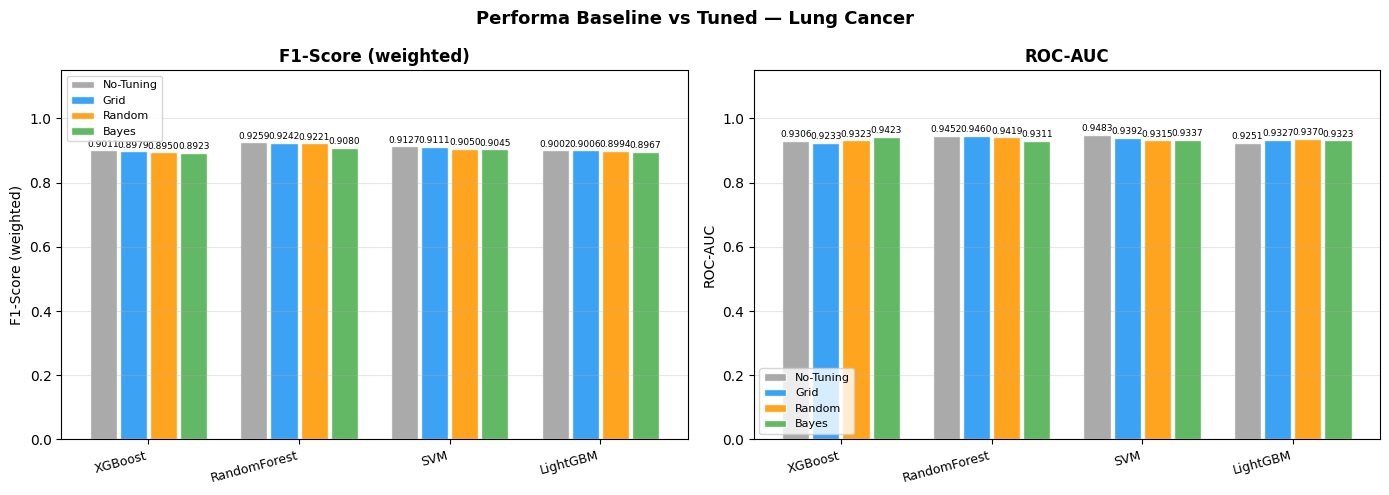

✅ Tersimpan: perf_Lung_Cancer.png


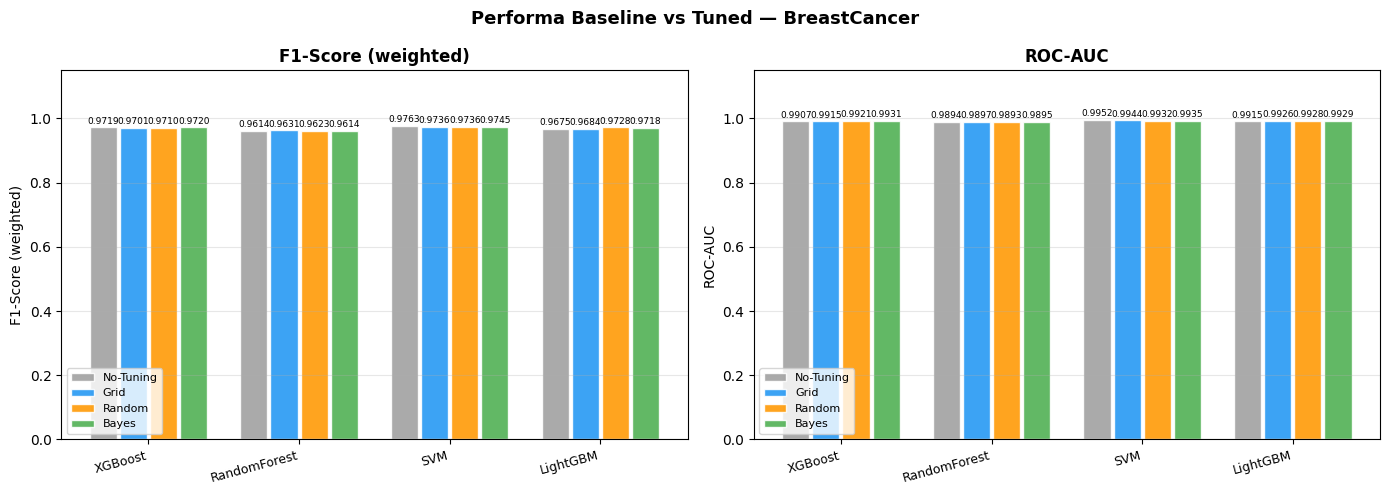

✅ Tersimpan: perf_BreastCancer.png


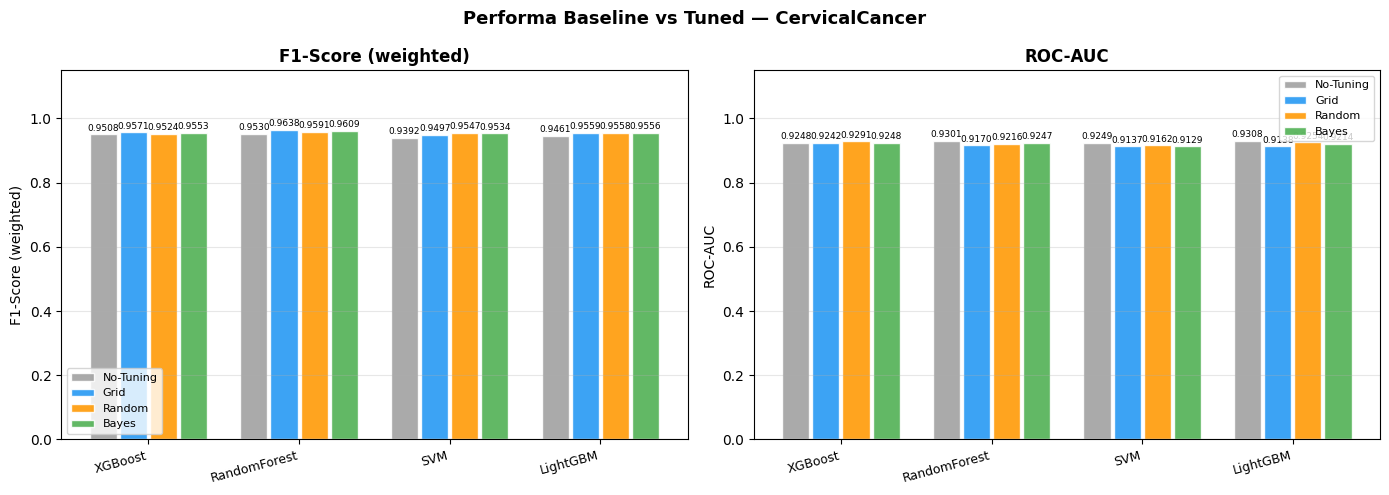

✅ Tersimpan: perf_CervicalCancer.png


In [49]:
# ============================================================
# 8.2 GROUPED BAR CHART — F1 & AUC PER DATASET
# ============================================================
colors_tuner = {'No-Tuning':'#9E9E9E','Grid':'#2196F3',
                'Random':'#FF9800','Bayes':'#4CAF50'}
x_off = {'No-Tuning':-0.3,'Grid':-0.1,'Random':0.1,'Bayes':0.3}

for ds_name in all_results:
    df_ds  = df_summary[df_summary['Dataset']==ds_name]
    models = MODEL_NAMES
    x      = np.arange(len(models))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Performa Baseline vs Tuned — {ds_name}', fontweight='bold', fontsize=13)

    for ax, metric, ylabel in zip(axes, ['Mean_F1','Mean_AUC'],
                                   ['F1-Score (weighted)','ROC-AUC']):
        for tuner in TUNER_NAMES:
            sub  = df_ds[df_ds['Tuner']==tuner]
            vals = [sub[sub['Model']==m][metric].values[0]
                    if len(sub[sub['Model']==m])>0 else 0 for m in models]
            bars = ax.bar(x + x_off[tuner], vals, 0.18,
                          label=tuner, color=colors_tuner[tuner],
                          edgecolor='white', alpha=0.88)
            for bar, v in zip(bars, vals):
                if v > 0:
                    ax.text(bar.get_x()+bar.get_width()/2,
                            bar.get_height()+0.005, f'{v:.4f}',
                            ha='center', va='bottom', fontsize=6.5)

        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
        ax.set_ylabel(ylabel); ax.set_ylim(0, 1.15)
        ax.set_title(ylabel, fontweight='bold')
        ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    fname = f'perf_{ds_name.replace(" ","_")}.png'
    plt.savefig(save_out(fname), dpi=130, bbox_inches='tight')
    plt.show()
    print(f"✅ Tersimpan: {fname}")

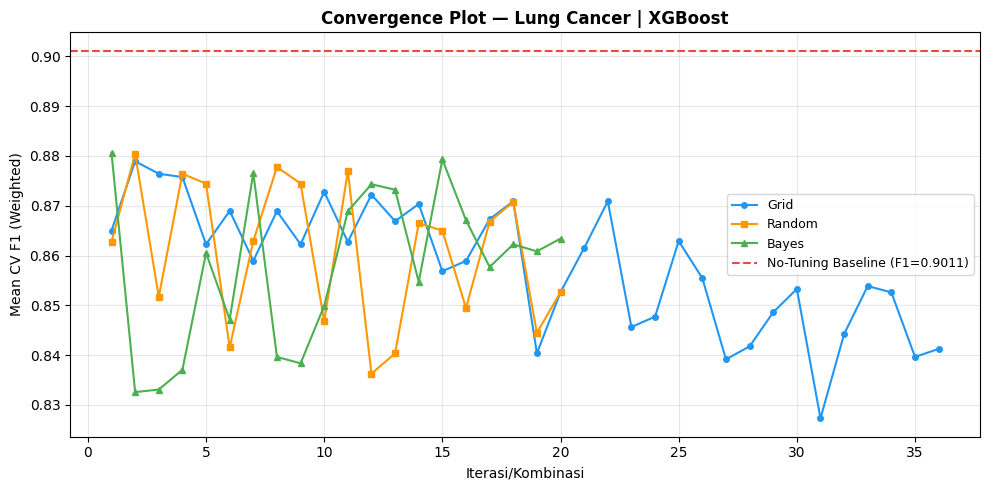

✅ Convergence plot tersimpan: conv_Lung_Cancer_XGBoost.png


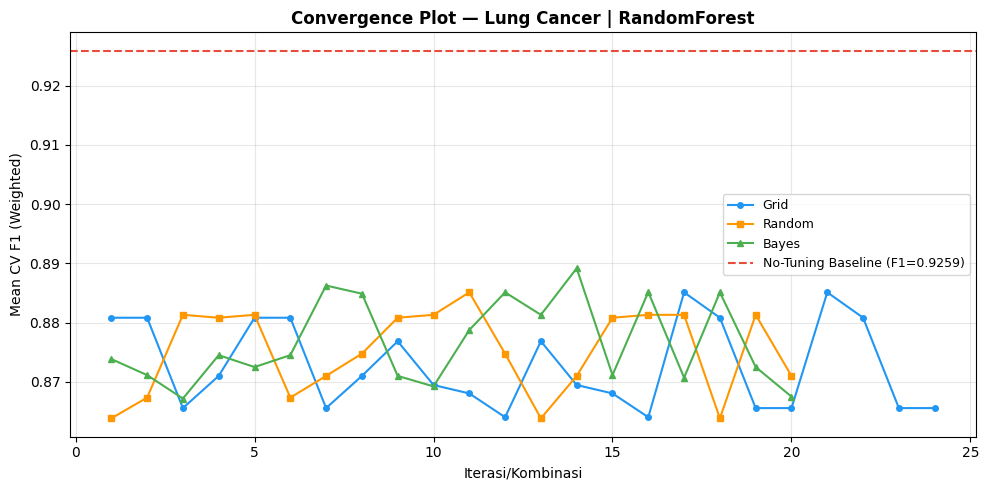

✅ Convergence plot tersimpan: conv_Lung_Cancer_RandomForest.png


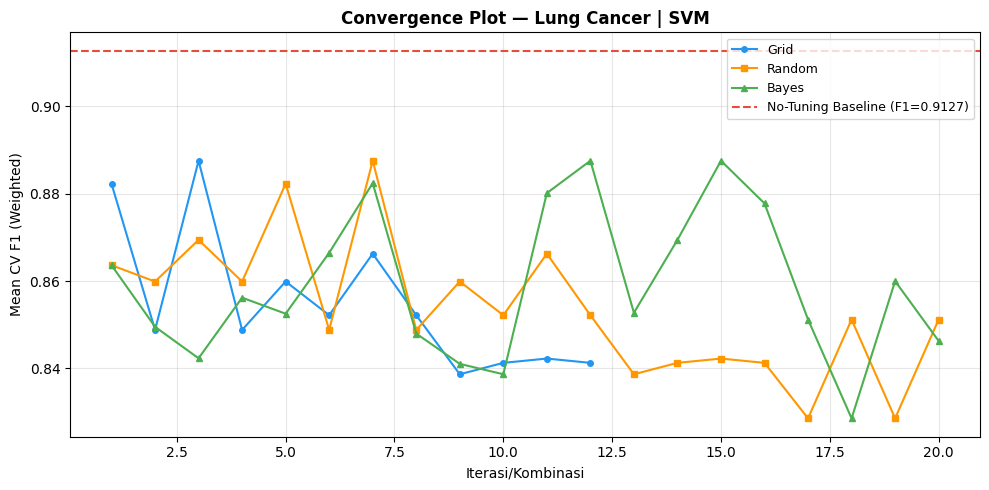

✅ Convergence plot tersimpan: conv_Lung_Cancer_SVM.png


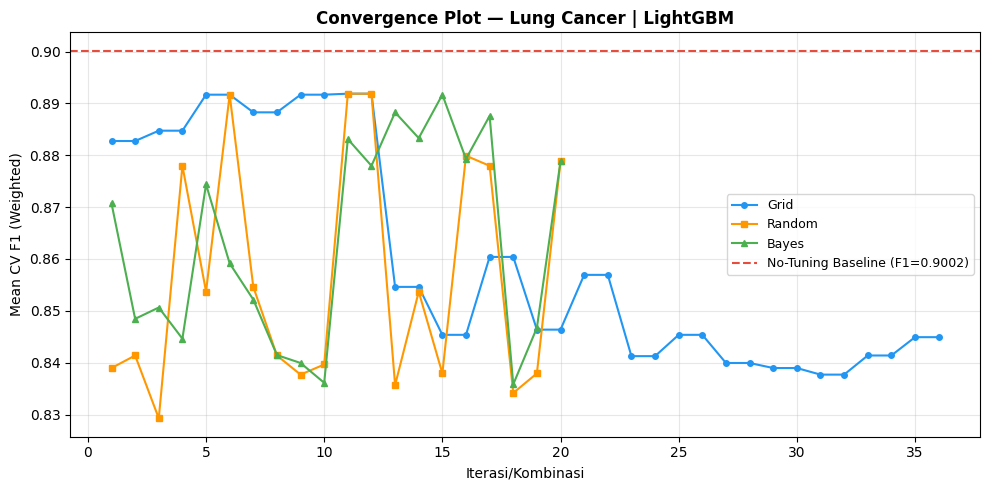

✅ Convergence plot tersimpan: conv_Lung_Cancer_LightGBM.png


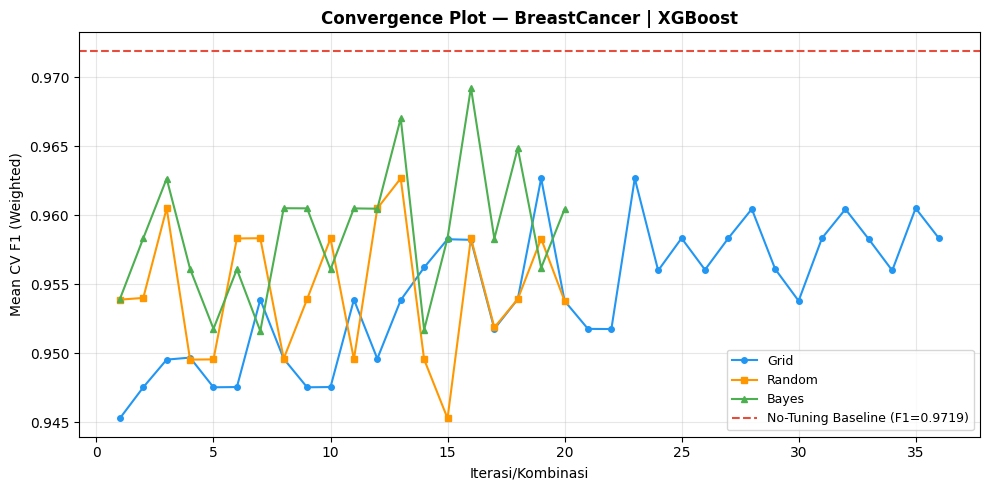

✅ Convergence plot tersimpan: conv_BreastCancer_XGBoost.png


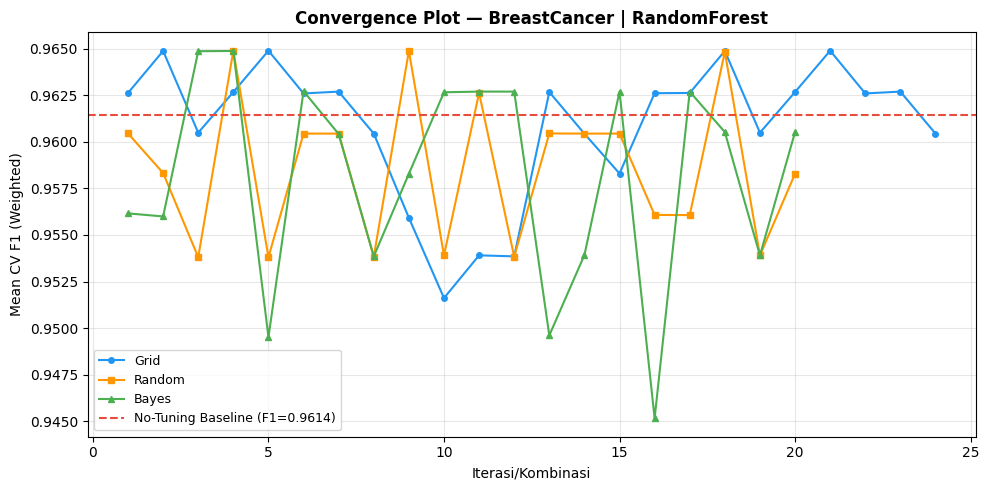

✅ Convergence plot tersimpan: conv_BreastCancer_RandomForest.png


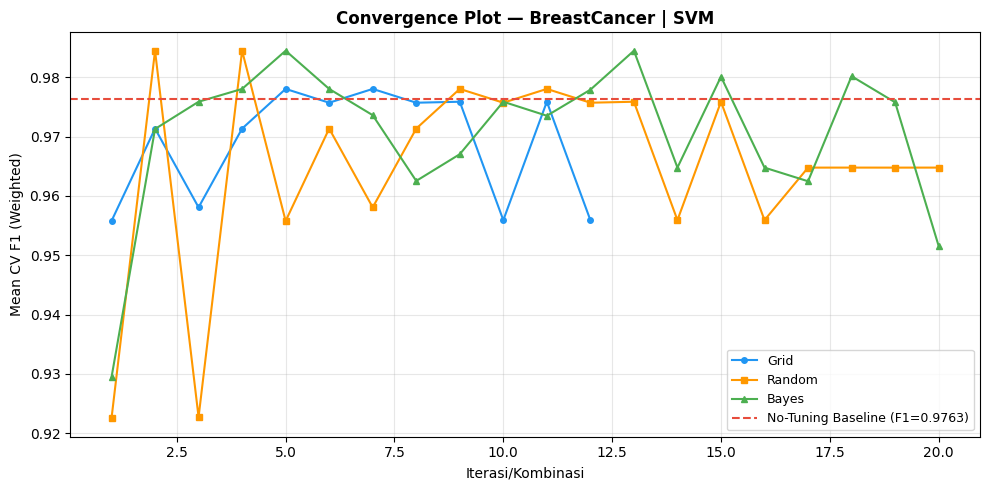

✅ Convergence plot tersimpan: conv_BreastCancer_SVM.png


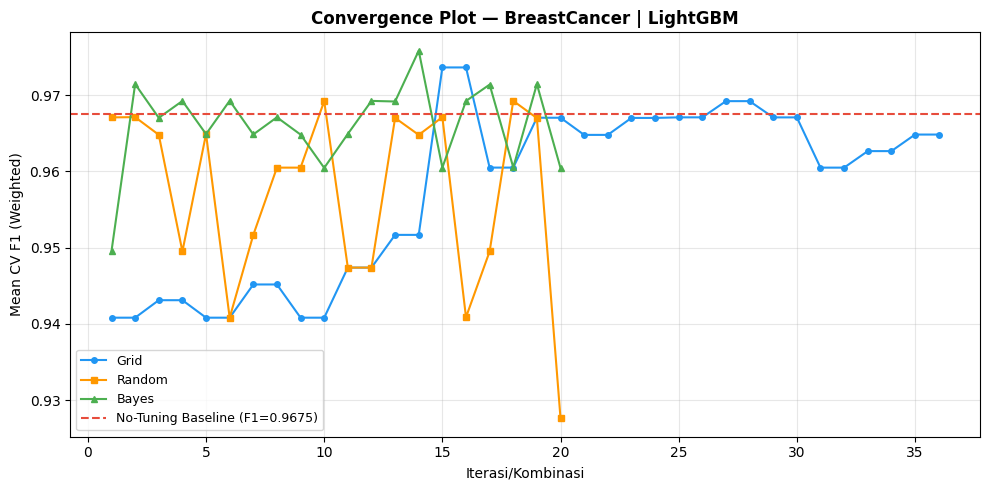

✅ Convergence plot tersimpan: conv_BreastCancer_LightGBM.png


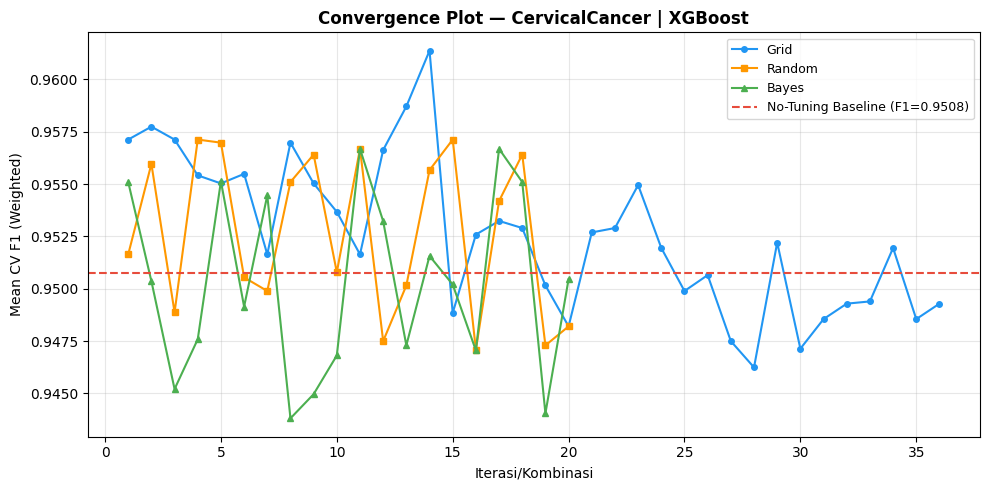

✅ Convergence plot tersimpan: conv_CervicalCancer_XGBoost.png


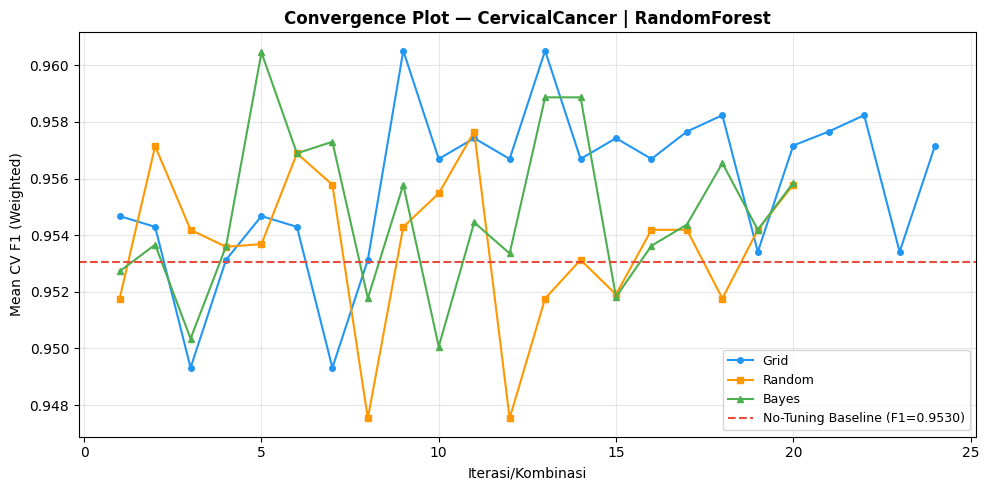

✅ Convergence plot tersimpan: conv_CervicalCancer_RandomForest.png


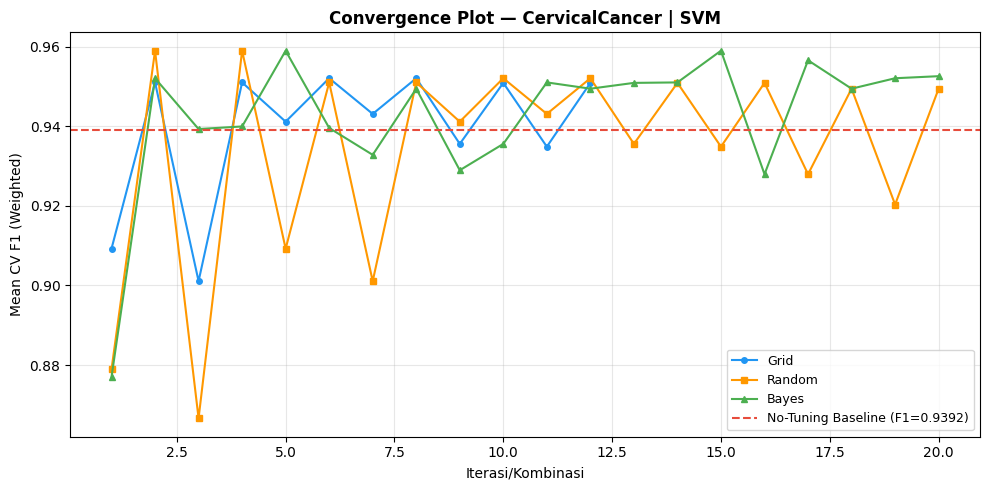

✅ Convergence plot tersimpan: conv_CervicalCancer_SVM.png


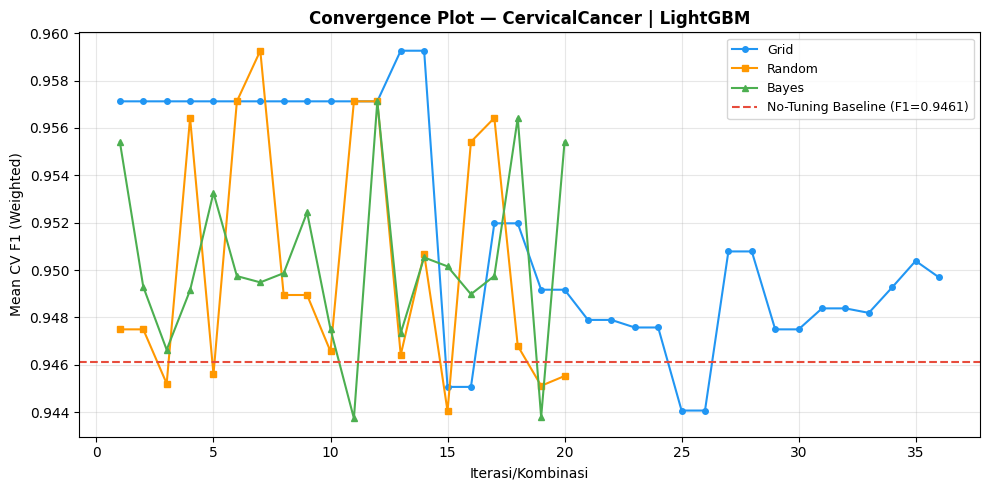

✅ Convergence plot tersimpan: conv_CervicalCancer_LightGBM.png


In [50]:
# ============================================================
# 8.3 CONVERGENCE PLOT — RATA-RATA ACROSS ALL RUNS
# ============================================================
# [FIX dari Paper_1_v2]: Plot menggunakan cv_results_ run TERAKHIR
# sebagai representasi, dengan garis baseline No-Tuning.

for ds_name in convergence_data:
    for model_name, cv_data in convergence_data[ds_name].items():
        if not cv_data:
            continue
        nt_mean = np.mean(all_results[ds_name][model_name]['No-Tuning']['f1'])

        plt.figure(figsize=(10, 5))
        for tuner, color, marker in [('Grid','#2196F3','o'),
                                      ('Random','#FF9800','s'),
                                      ('Bayes','#4CAF50','^')]:
            if tuner in cv_data and 'mean_test_score' in cv_data[tuner]:
                scores = cv_data[tuner]['mean_test_score']
                plt.plot(range(1, len(scores)+1), scores, label=tuner,
                         marker=marker, markersize=4, color=color)

        plt.axhline(y=nt_mean, color='#e74c3c', linestyle='--',
                    linewidth=1.5, label=f'No-Tuning Baseline (F1={nt_mean:.4f})')
        plt.xlabel('Iterasi/Kombinasi'); plt.ylabel('Mean CV F1 (Weighted)')
        plt.title(f'Convergence Plot — {ds_name} | {model_name}', fontweight='bold')
        plt.legend(fontsize=9); plt.grid(alpha=0.3)
        plt.tight_layout()
        fname = f'conv_{ds_name.replace(" ","_")}_{model_name.replace(" ","_")}.png'
        plt.savefig(save_out(fname), dpi=130)
        plt.show()
        plt.close()
        print(f"✅ Convergence plot tersimpan: {fname}")

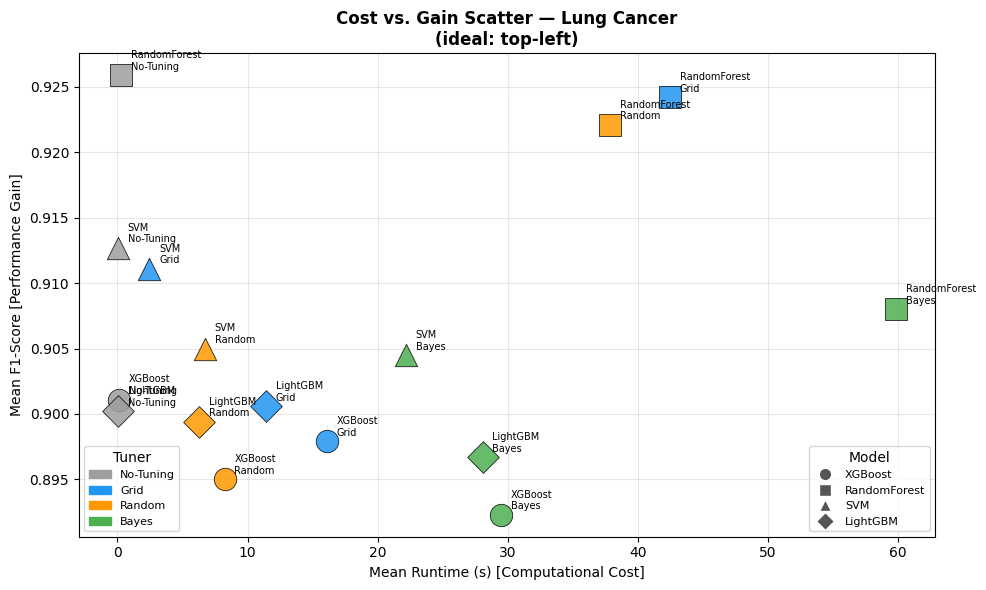

✅ Scatter plot tersimpan: scatter_Lung_Cancer.png


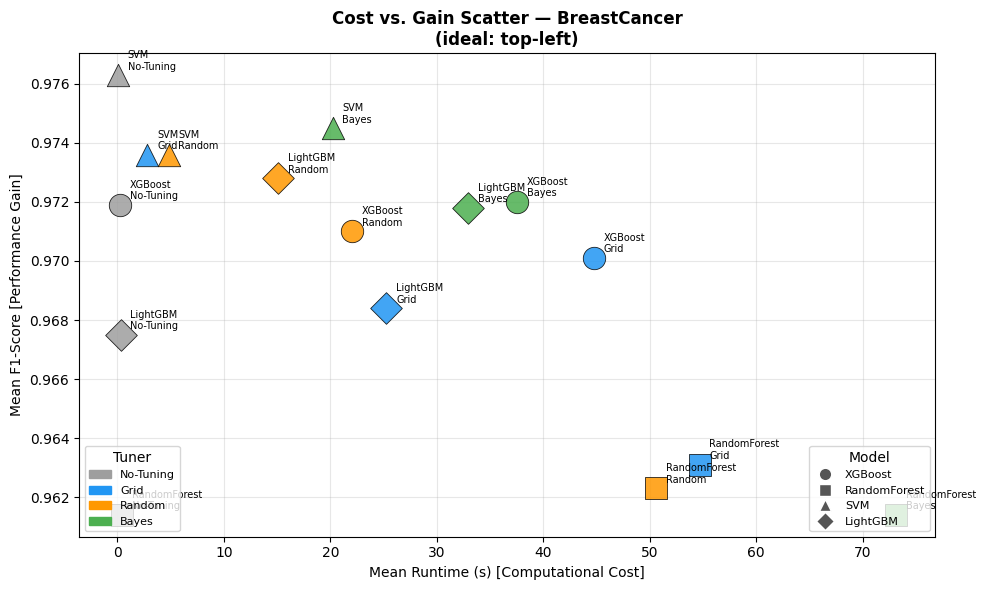

✅ Scatter plot tersimpan: scatter_BreastCancer.png


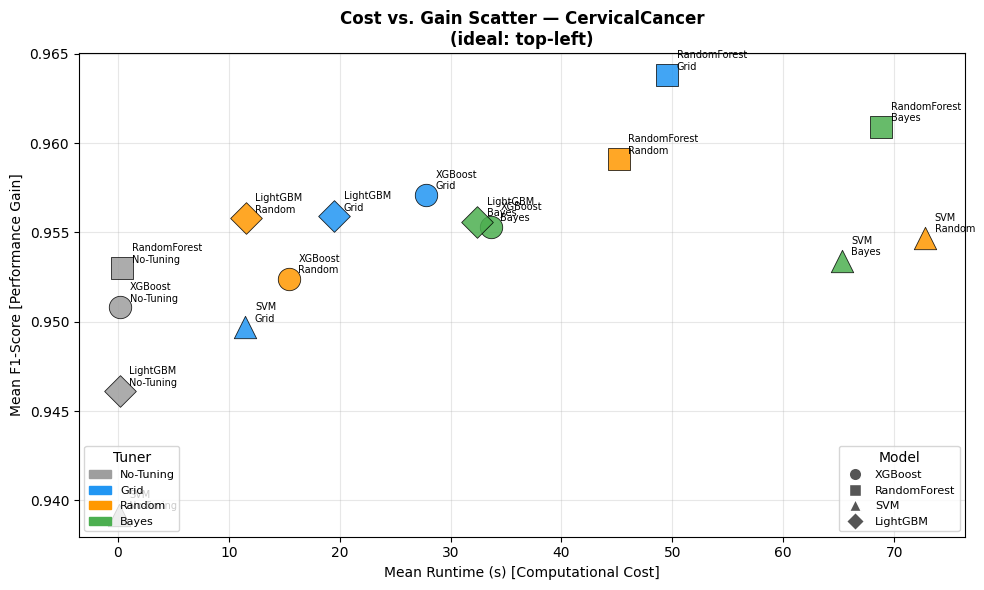

✅ Scatter plot tersimpan: scatter_CervicalCancer.png


In [51]:
# ============================================================
# 8.4 COST-GAIN SCATTER — Runtime vs F1
# ============================================================
for ds_name in all_results:
    df_ds   = df_summary[df_summary['Dataset']==ds_name]
    markers = {'XGBoost':'o','RandomForest':'s','SVM':'^','LightGBM':'D'}

    plt.figure(figsize=(10, 6))
    for _, row in df_ds.iterrows():
        plt.scatter(row['Mean_RT'], row['Mean_F1'], s=260,
                    c=colors_tuner[row['Tuner']], marker=markers[row['Model']],
                    alpha=0.85, edgecolors='black', linewidths=0.6, zorder=3)
        plt.annotate(f"{row['Model']}\n{row['Tuner']}",
                     (row['Mean_RT'], row['Mean_F1']),
                     textcoords='offset points', xytext=(7,4), fontsize=7)

    mh = [Line2D([0],[0],marker=mk,color='w',markerfacecolor='#555',
                 markersize=9, label=m) for m,mk in markers.items()]
    th = [mpatches.Patch(color=c, label=t) for t,c in colors_tuner.items()]
    l1 = plt.legend(handles=mh, title='Model', loc='lower right', fontsize=8)
    plt.gca().add_artist(l1)
    plt.legend(handles=th, title='Tuner', loc='lower left', fontsize=8)
    plt.xlabel('Mean Runtime (s) [Computational Cost]')
    plt.ylabel('Mean F1-Score [Performance Gain]')
    plt.title(f'Cost vs. Gain Scatter — {ds_name}\n(ideal: top-left)',
              fontweight='bold')
    plt.grid(alpha=0.3); plt.tight_layout()
    fname = f'scatter_{ds_name.replace(" ","_")}.png'
    plt.savefig(save_out(fname), dpi=130, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"✅ Scatter plot tersimpan: {fname}")

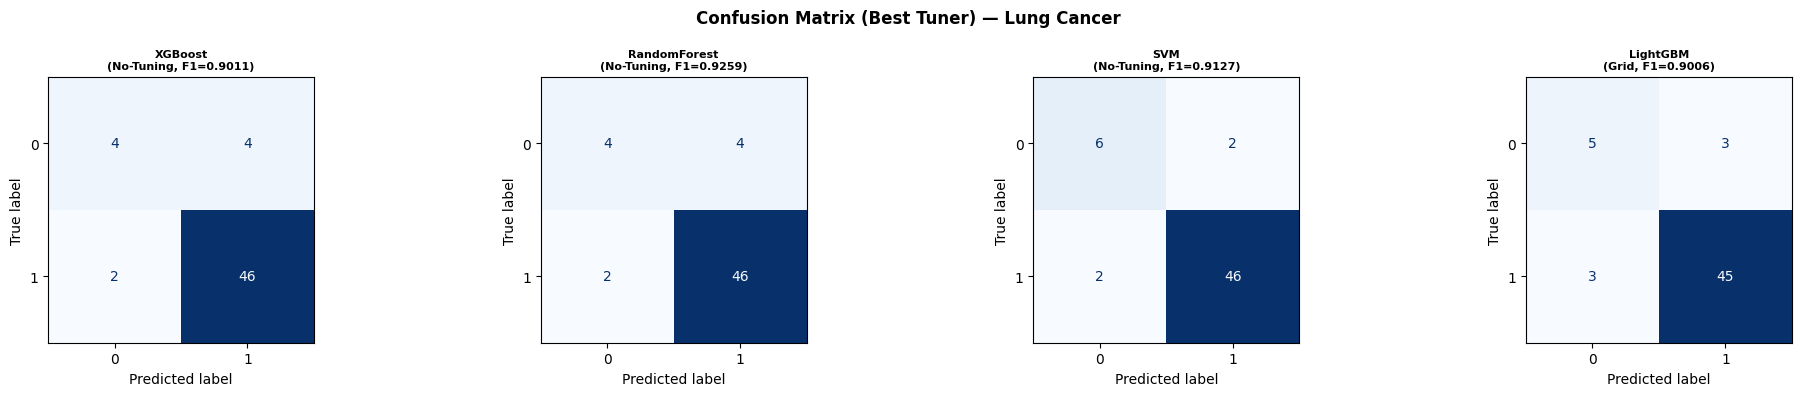

✅ Confusion matrix tersimpan: cm_Lung_Cancer.png


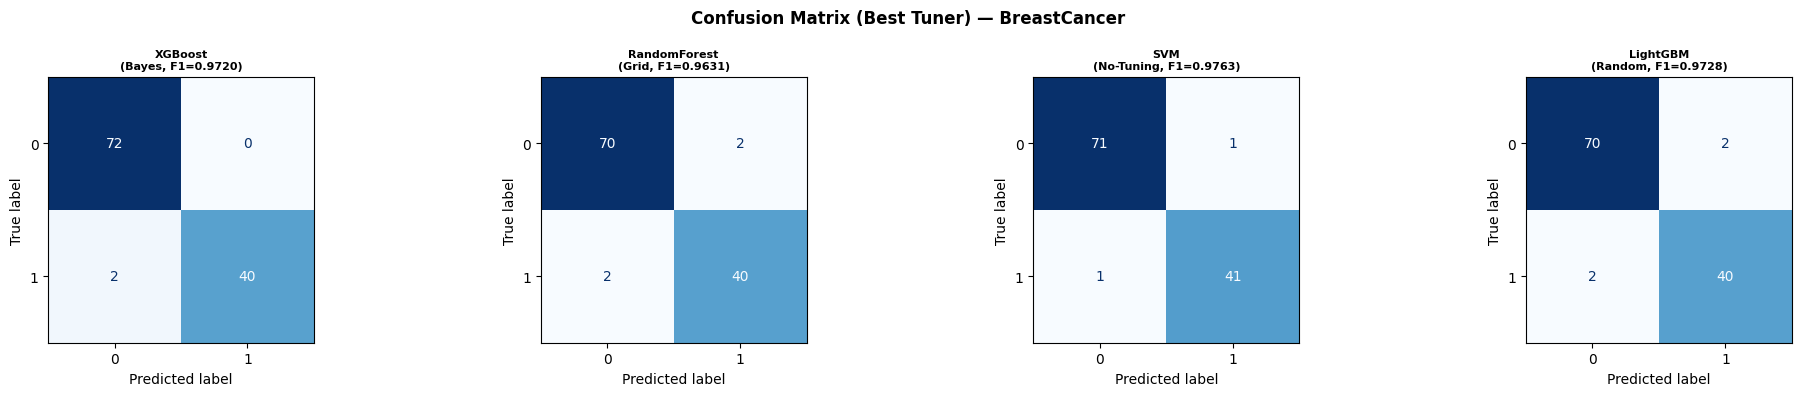

✅ Confusion matrix tersimpan: cm_BreastCancer.png


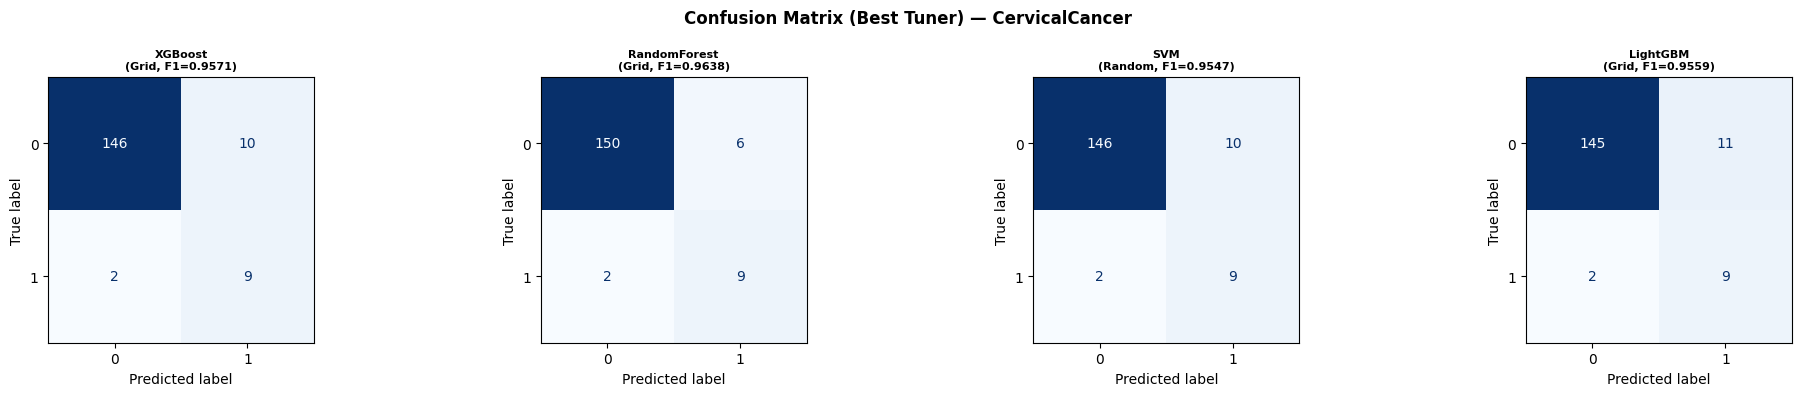

✅ Confusion matrix tersimpan: cm_CervicalCancer.png


In [53]:
# ============================================================
# 8.5 CONFUSION MATRIX — BEST TUNER PER MODEL PER DATASET
# ============================================================
for ds_name, data in datasets_split.items():
    X_all = np.vstack([data['X_train'], data['X_test']])
    y_all = np.concatenate([data['y_train'], data['y_test']])
    X_tr_arr, X_te_arr, y_tr, y_te = train_test_split(
        X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED
    )
    # Convert back to DataFrame
    original_cols = data['X'].columns
    X_tr = pd.DataFrame(X_tr_arr, columns=original_cols)
    X_te = pd.DataFrame(X_te_arr, columns=original_cols)

    pre = data['preprocessor']

    fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(5*len(MODEL_NAMES), 4))
    fig.suptitle(f'Confusion Matrix (Best Tuner) — {ds_name}', fontweight='bold')

    for ax, model_name in zip(axes, MODEL_NAMES):
        buf = all_results[ds_name][model_name]
        # Pilih tuner dengan mean F1 tertinggi
        best_tuner = max(TUNER_NAMES, key=lambda t: np.mean(buf[t]['f1']))
        best_f1    = np.mean(buf[best_tuner]['f1'])

        # Re-train dengan best tuner untuk CM
        pipe = make_pipeline(pre, build_model(model_name, SEED))
        if best_tuner == 'No-Tuning':
            pipe.fit(X_tr, y_tr)
        elif best_tuner == 'Grid':
            gs = GridSearchCV(pipe, PARAM_GRID[model_name],
                              scoring='f1_weighted',
                              cv=StratifiedKFold(CV_FOLDS, shuffle=True, random_state=SEED),
                              n_jobs=-1)
            gs.fit(X_tr, y_tr); pipe = gs.best_estimator_
        elif best_tuner == 'Random':
            rs = RandomizedSearchCV(pipe, PARAM_RANDOM[model_name],
                                    n_iter=N_ITER_TUNING, scoring='f1_weighted',
                                    cv=StratifiedKFold(CV_FOLDS, shuffle=True, random_state=SEED),
                                    random_state=SEED, n_jobs=-1)
            rs.fit(X_tr, y_tr); pipe = rs.best_estimator_
        else:
            bs = BayesSearchCV(pipe, PARAM_BAYES[model_name],
                               n_iter=N_ITER_TUNING, scoring='f1_weighted',
                               cv=StratifiedKFold(CV_FOLDS, shuffle=True, random_state=SEED),
                               random_state=SEED, n_jobs=-1)
            bs.fit(X_tr, y_tr); pipe = bs.best_estimator_

        y_pred = pipe.predict(X_te)
        cm     = confusion_matrix(y_te, y_pred)
        ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{model_name}\n({best_tuner}, F1={best_f1:.4f})', fontsize=8, fontweight='bold')

    plt.tight_layout()
    fname = f'cm_{ds_name.replace(" ","_")}.png'
    plt.savefig(save_out(fname), dpi=130, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"✅ Confusion matrix tersimpan: {fname}")

## 🧠 Bagian 9: SHAP Feature Importance + Cost-Gain Analysis

⏳ Menghitung SHAP values...


📌 Lung Cancer | XGBoost


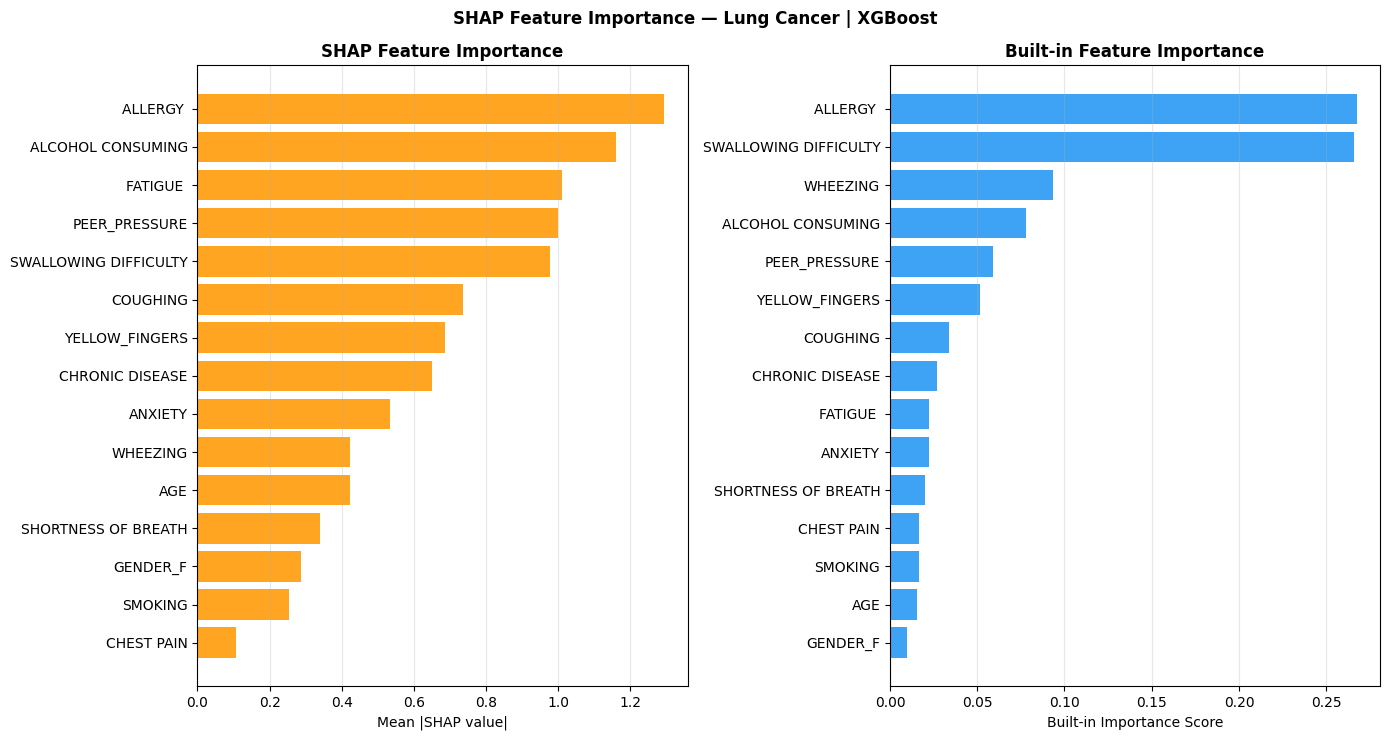

✅ SHAP tersimpan: shap_Lung_Cancer_XGBoost.png

📌 Lung Cancer | RandomForest


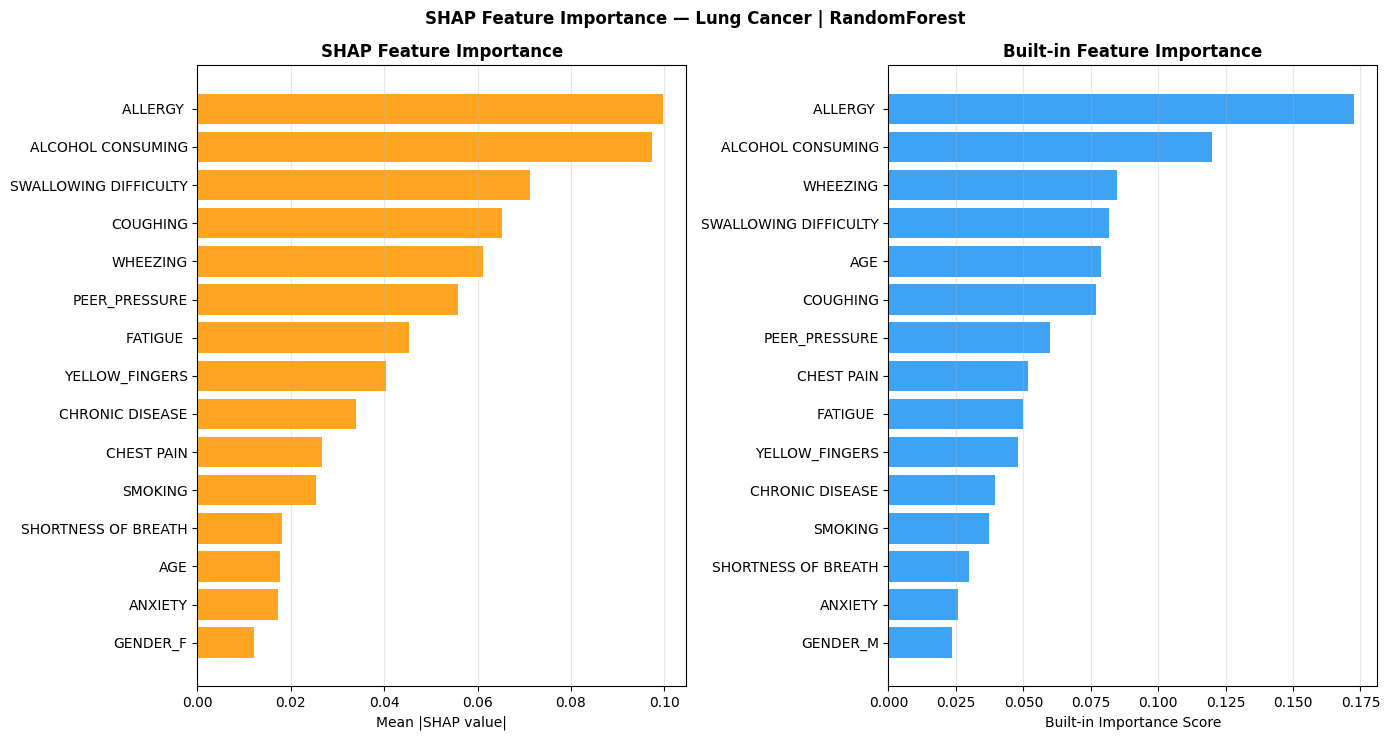

✅ SHAP tersimpan: shap_Lung_Cancer_RandomForest.png

📌 Lung Cancer | LightGBM


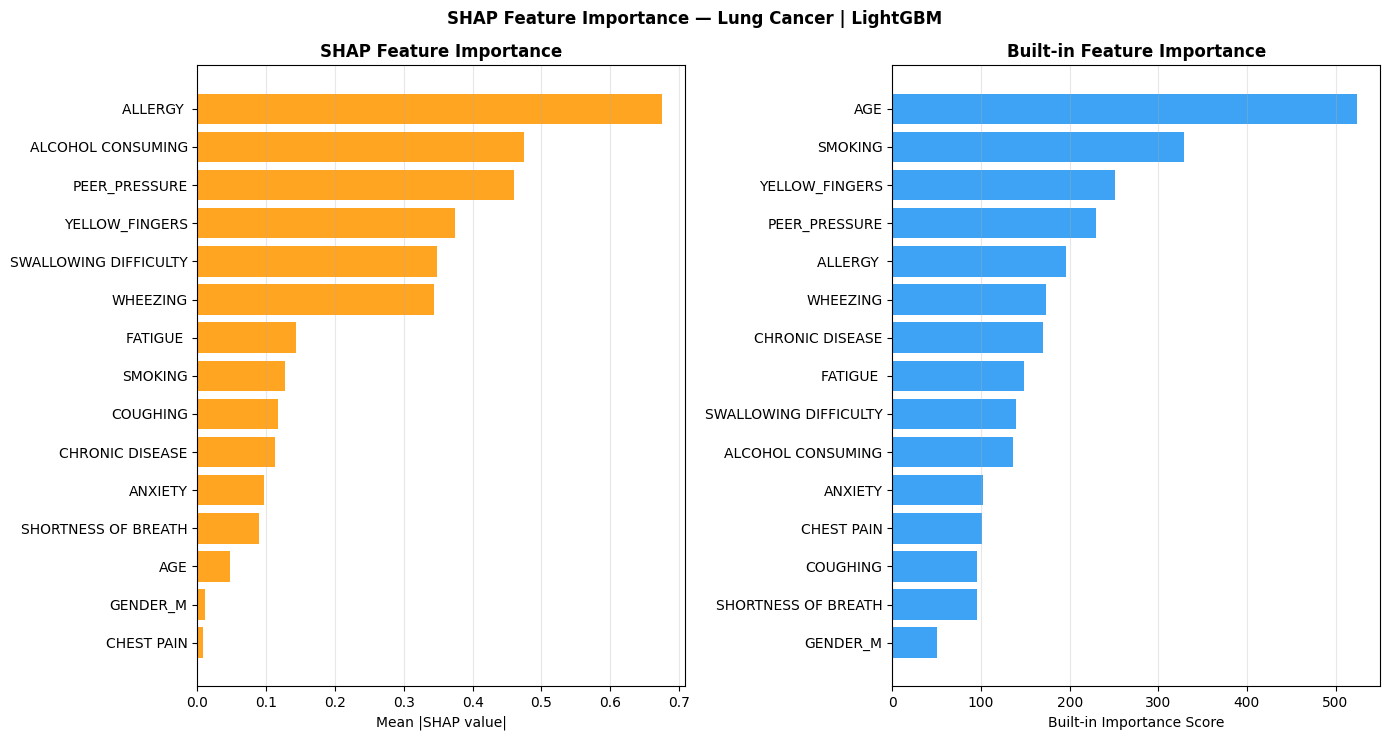

✅ SHAP tersimpan: shap_Lung_Cancer_LightGBM.png

📌 BreastCancer | XGBoost


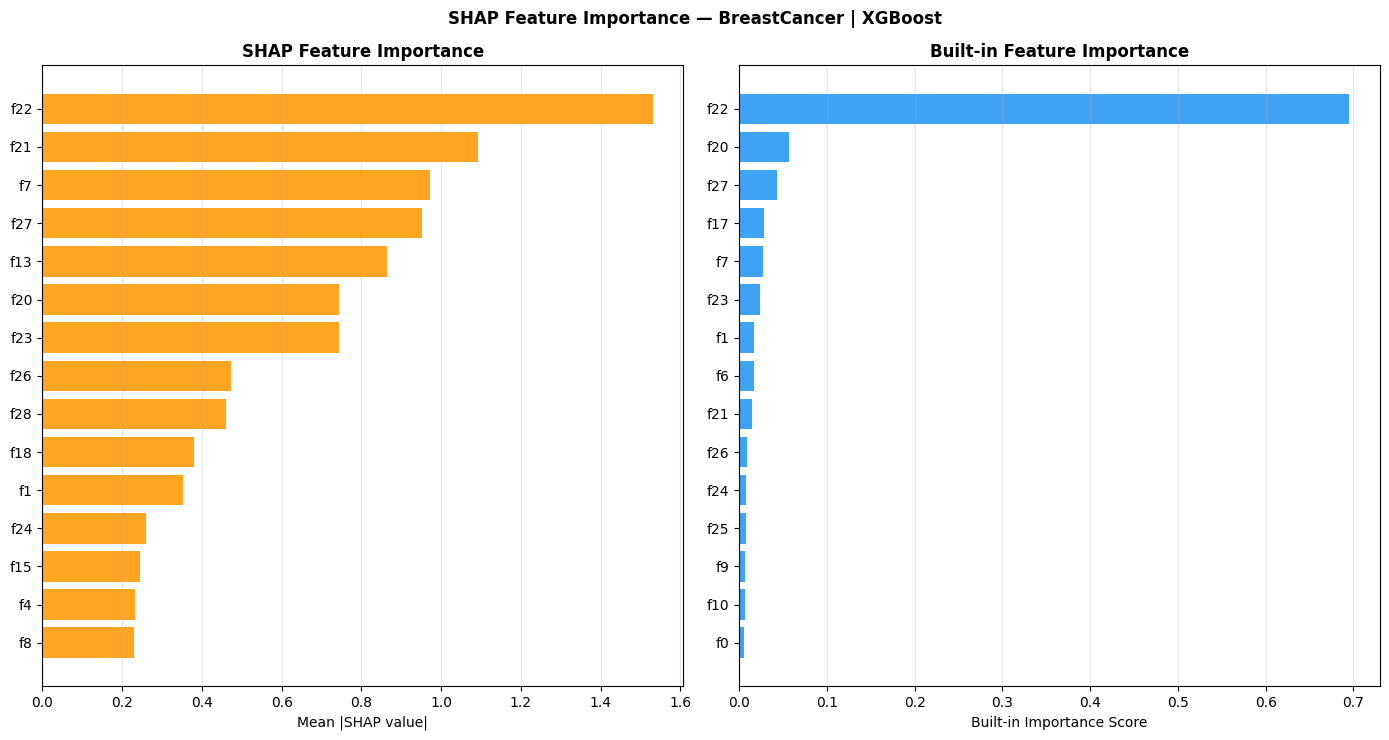

✅ SHAP tersimpan: shap_BreastCancer_XGBoost.png

📌 BreastCancer | RandomForest


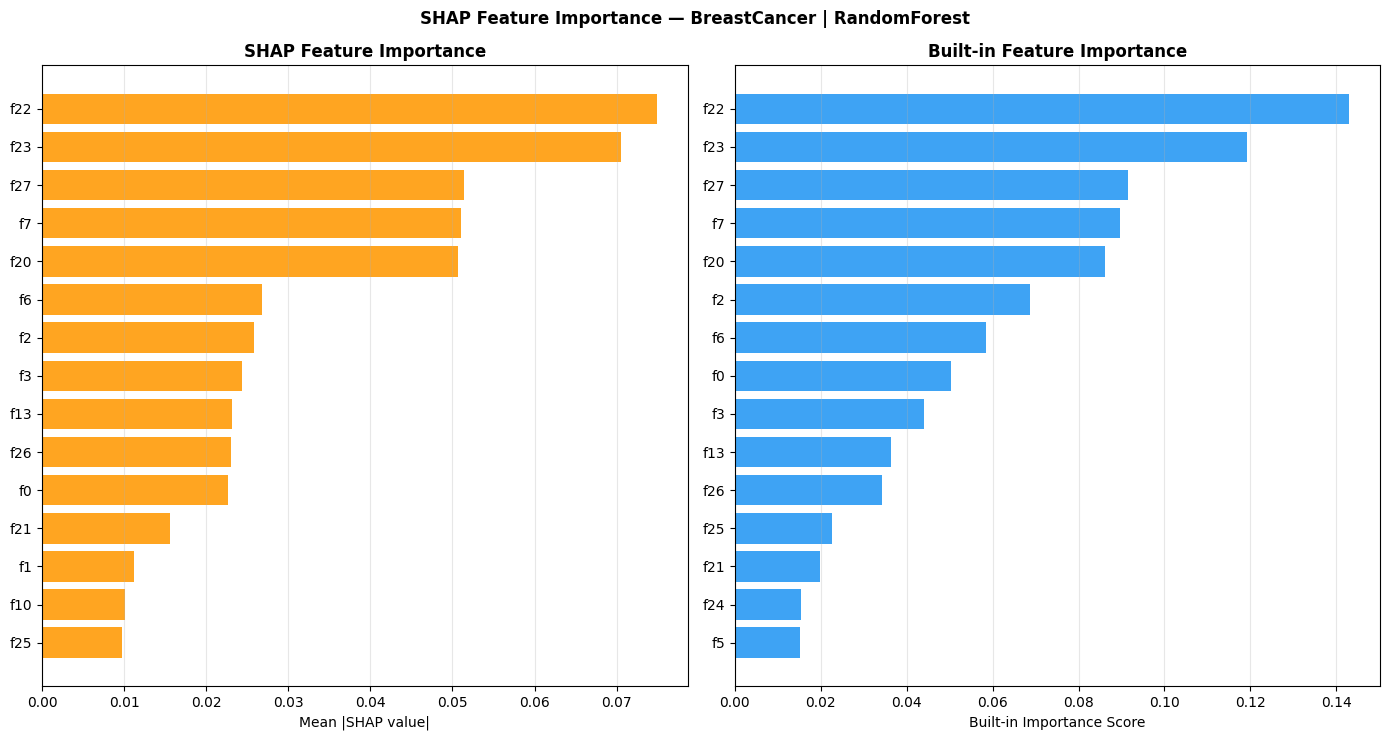

✅ SHAP tersimpan: shap_BreastCancer_RandomForest.png

📌 BreastCancer | LightGBM


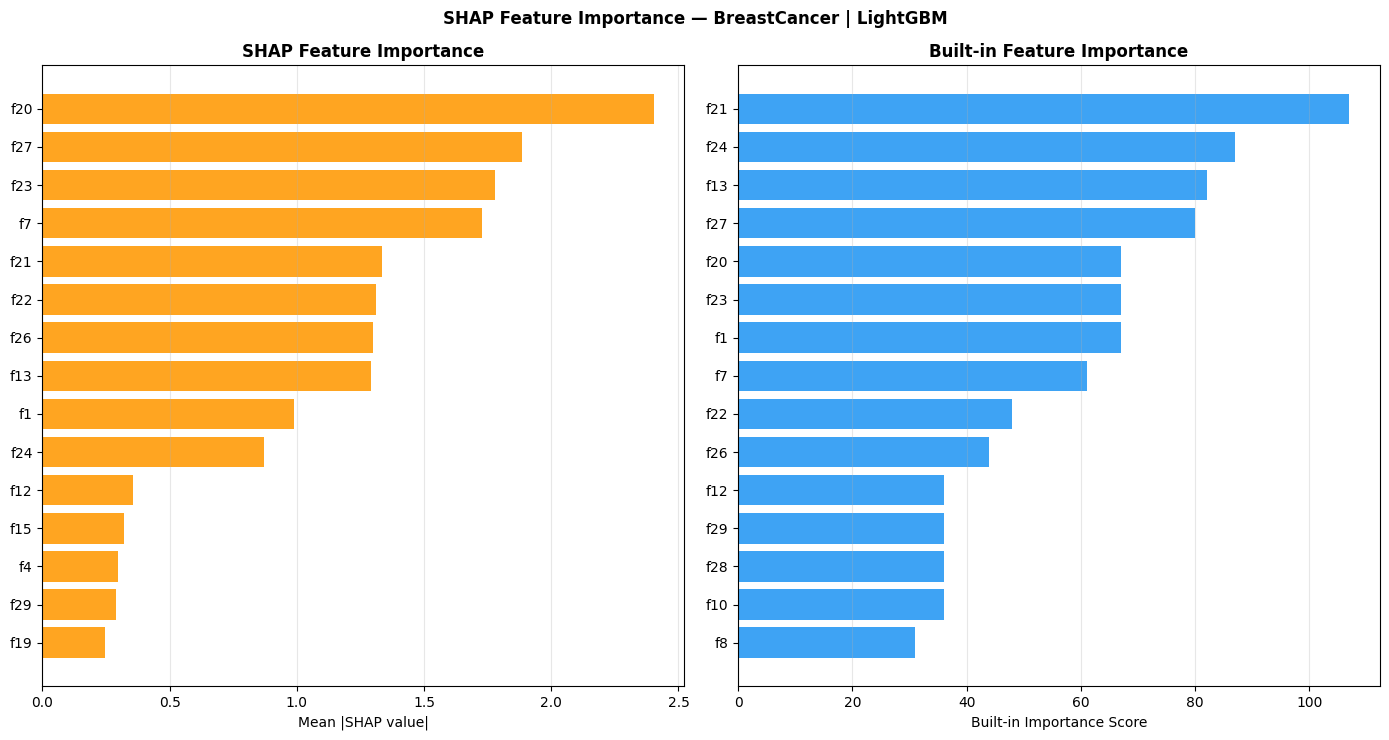

✅ SHAP tersimpan: shap_BreastCancer_LightGBM.png

📌 CervicalCancer | XGBoost


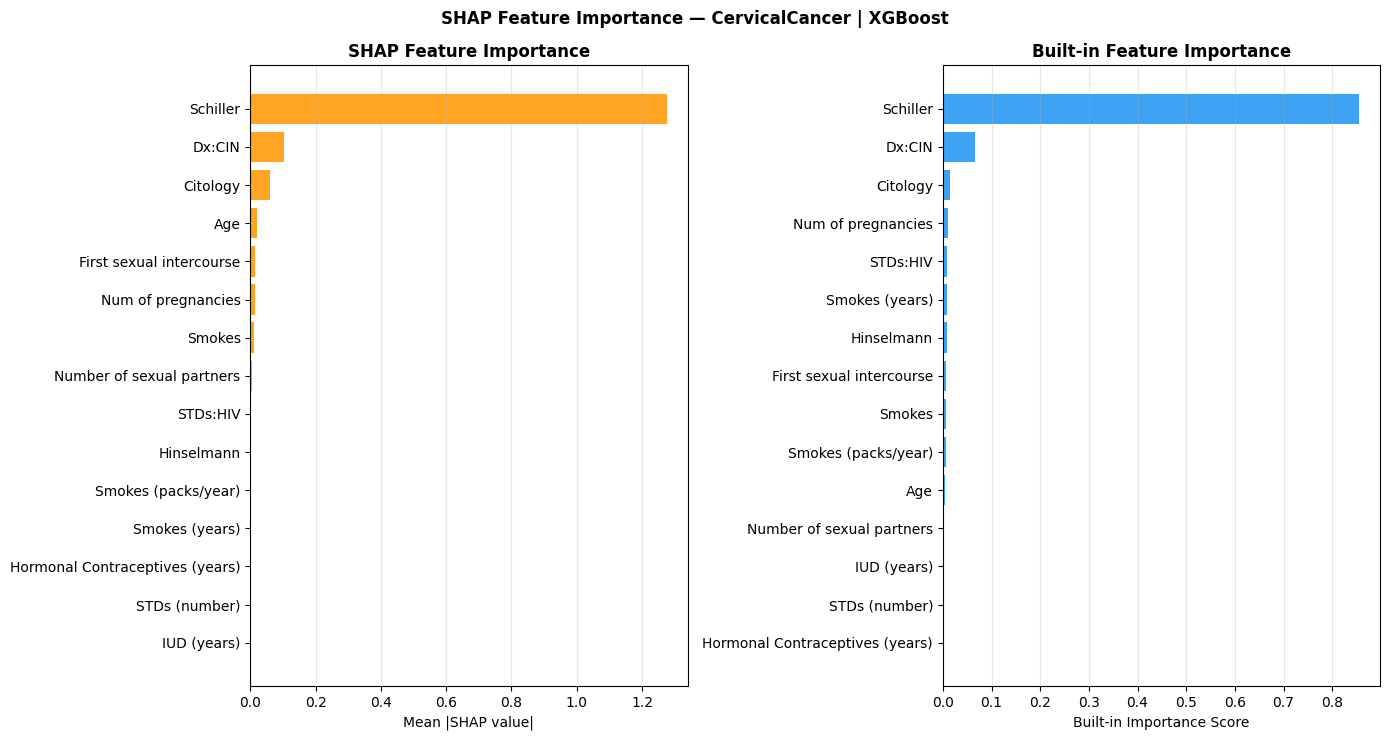

✅ SHAP tersimpan: shap_CervicalCancer_XGBoost.png

📌 CervicalCancer | RandomForest


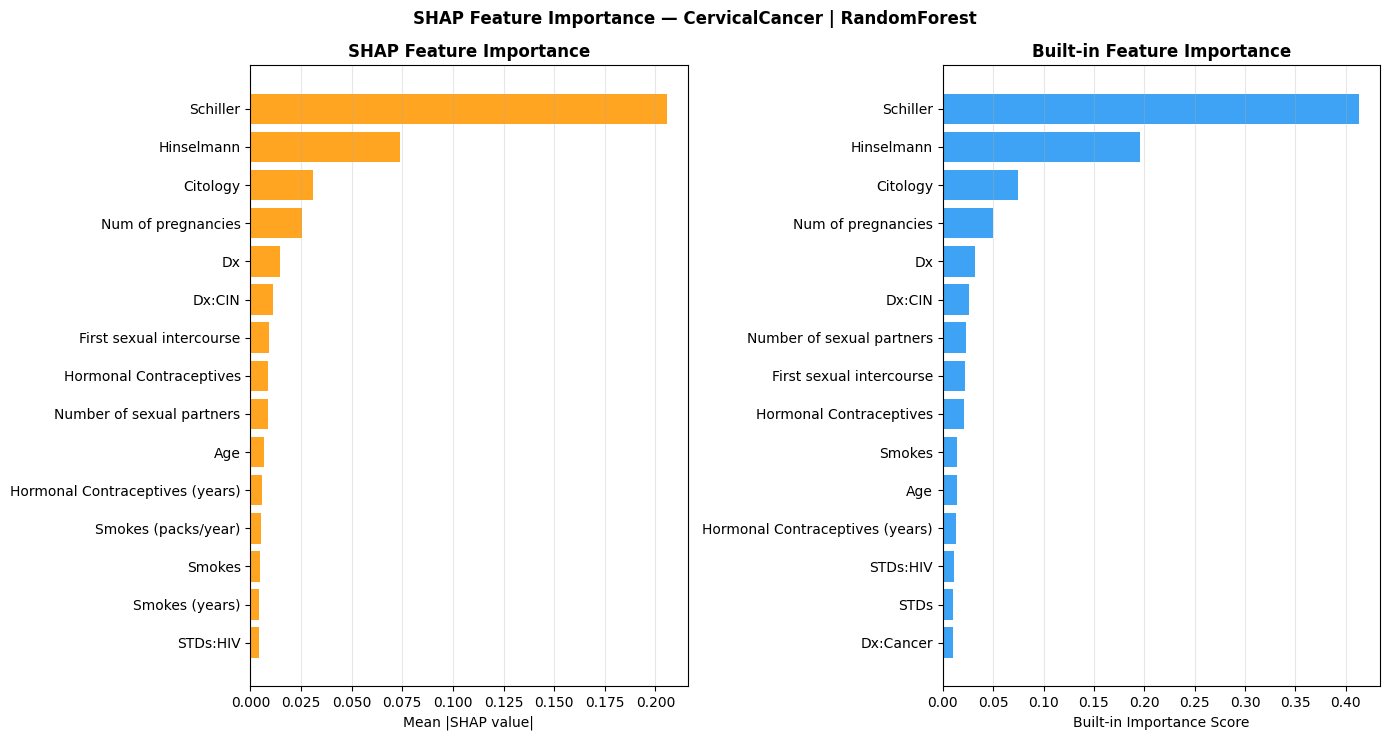

✅ SHAP tersimpan: shap_CervicalCancer_RandomForest.png

📌 CervicalCancer | LightGBM


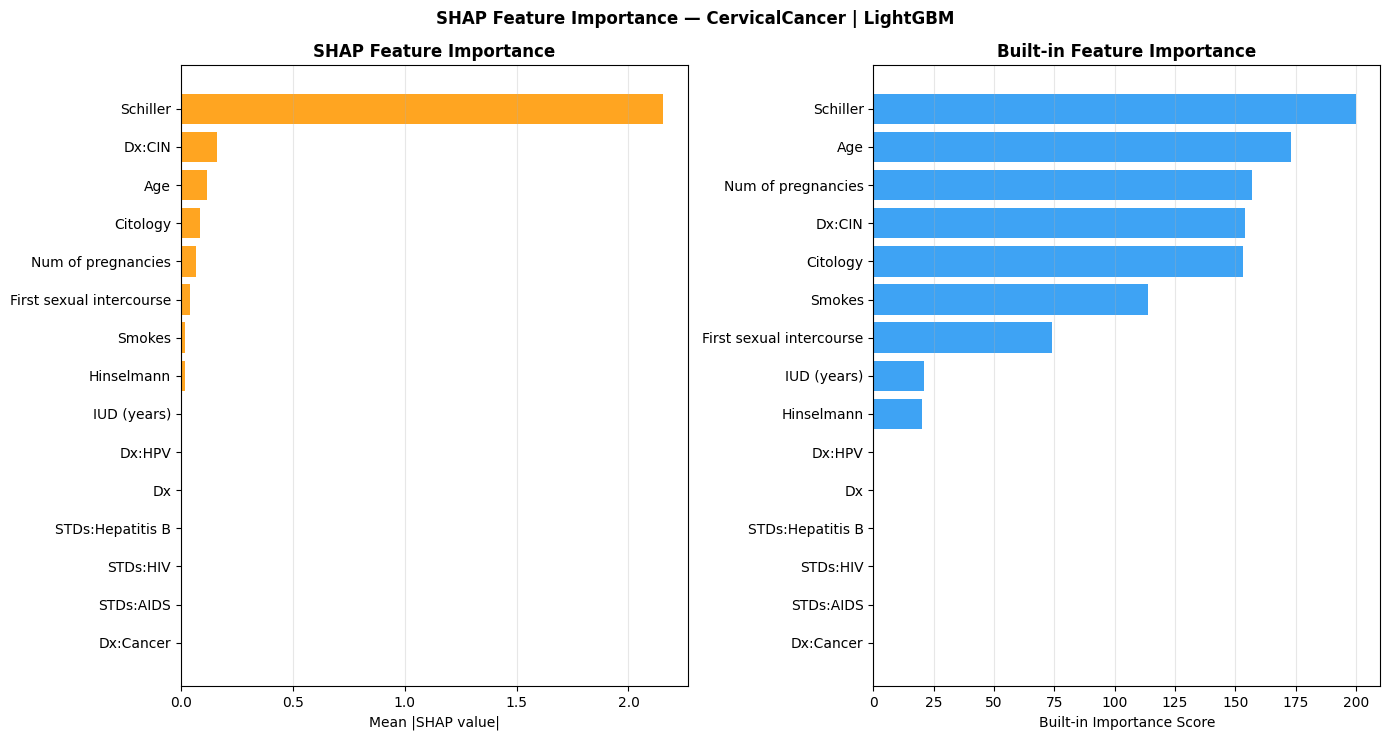

✅ SHAP tersimpan: shap_CervicalCancer_LightGBM.png


In [73]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# ============================================================
# 9.1 SHAP FEATURE IMPORTANCE — TREE-BASED MODELS
# ============================================================

print("⏳ Menghitung SHAP values...\n")

for ds_name, data in datasets_split.items():

    X_all = np.vstack([data['X_train'], data['X_test']])
    y_all = np.concatenate([data['y_train'], data['y_test']])

    X_tr_arr, X_te_arr, y_tr, y_te = train_test_split(
        X_all,
        y_all,
        test_size=0.2,
        stratify=y_all,
        random_state=SEED
    )

    pre = data['preprocessor']
    num_cols = data['num_cols']
    cat_cols = data['cat_cols']
    original_cols = data['X'].columns

    X_tr = pd.DataFrame(X_tr_arr, columns=original_cols)
    X_te = pd.DataFrame(X_te_arr, columns=original_cols)

    for model_name in ['XGBoost', 'RandomForest', 'LightGBM']:

        print(f"\n📌 {ds_name} | {model_name}")

        try:

            # ====================================================
            # Build pipeline
            # ====================================================

            pipe = make_pipeline(
                pre,
                build_model(model_name, SEED)
            )

            buf = all_results[ds_name][model_name]

            best_tuner = max(
                TUNER_NAMES,
                key=lambda t: np.mean(buf[t]['f1'])
            )

            if best_tuner == 'No-Tuning':

                pipe.fit(X_tr, y_tr)

            elif best_tuner == 'Grid':

                gs = GridSearchCV(
                    pipe,
                    PARAM_GRID[model_name],
                    scoring='f1_weighted',
                    cv=StratifiedKFold(
                        CV_FOLDS,
                        shuffle=True,
                        random_state=SEED
                    ),
                    n_jobs=-1
                )

                gs.fit(X_tr, y_tr)
                pipe = gs.best_estimator_

            elif best_tuner == 'Random':

                rs = RandomizedSearchCV(
                    pipe,
                    PARAM_RANDOM[model_name],
                    n_iter=N_ITER_TUNING,
                    scoring='f1_weighted',
                    cv=StratifiedKFold(
                        CV_FOLDS,
                        shuffle=True,
                        random_state=SEED
                    ),
                    random_state=SEED,
                    n_jobs=-1
                )

                rs.fit(X_tr, y_tr)
                pipe = rs.best_estimator_

            elif best_tuner == 'Bayes':

                bs = BayesSearchCV(
                    pipe,
                    PARAM_BAYES[model_name],
                    n_iter=N_ITER_TUNING,
                    scoring='f1_weighted',
                    cv=StratifiedKFold(
                        CV_FOLDS,
                        shuffle=True,
                        random_state=SEED
                    ),
                    random_state=SEED,
                    n_jobs=-1
                )

                bs.fit(X_tr, y_tr)
                pipe = bs.best_estimator_

            # ====================================================
            # Extract fitted objects
            # ====================================================

            pre_fitted = pipe.named_steps['pre']
            clf = pipe.named_steps['clf']

            # ====================================================
            # Transform data
            # ====================================================

            X_te_proc = pre_fitted.transform(X_te)

            # convert sparse -> dense
            if hasattr(X_te_proc, "toarray"):
                X_te_proc = X_te_proc.toarray()

            feat_names = get_feature_names(
                pre_fitted,
                num_cols,
                cat_cols
            )

            if len(feat_names) != X_te_proc.shape[1]:
                feat_names = [
                    f"f{i}" for i in range(X_te_proc.shape[1])
                ]

            # ====================================================
            # Sample data for SHAP
            # ====================================================

            n_samp = min(200, X_te_proc.shape[0])

            idx_s = np.random.choice(
                X_te_proc.shape[0],
                n_samp,
                replace=False
            )

            X_shap = X_te_proc[idx_s]

            # ====================================================
            # SHAP EXPLAINER
            # ====================================================

            if model_name == 'RandomForest':

                explainer = shap.Explainer(clf)

            else:

                explainer = shap.TreeExplainer(clf)

            shap_values = explainer(X_shap)

            # ====================================================
            # Handle multiclass/binary safely
            # ====================================================

            values = shap_values.values

            if values.ndim == 3:
                shap_abs = np.mean(np.abs(values), axis=2)
            else:
                shap_abs = np.abs(values)

            mean_shap = shap_abs.mean(axis=0)

            # ====================================================
            # Top features
            # ====================================================

            top_n = min(15, len(mean_shap))

            idx_top = np.argsort(mean_shap)[::-1][:top_n]

            labels_top = [feat_names[i] for i in idx_top]

            # ====================================================
            # Plot
            # ====================================================

            fig, axes = plt.subplots(
                1,
                2,
                figsize=(14, max(5, top_n * 0.4 + 1.5))
            )

            fig.suptitle(
                f'SHAP Feature Importance — {ds_name} | {model_name}',
                fontweight='bold'
            )

            # ----------------------------------------------------
            # SHAP Importance
            # ----------------------------------------------------

            axes[0].barh(
                labels_top[::-1],
                mean_shap[idx_top][::-1],
                color='#FF9800',
                alpha=0.87
            )

            axes[0].set_xlabel('Mean |SHAP value|')

            axes[0].set_title(
                'SHAP Feature Importance',
                fontweight='bold'
            )

            axes[0].grid(axis='x', alpha=0.3)

            # ----------------------------------------------------
            # Built-in importance
            # ----------------------------------------------------

            if hasattr(clf, 'feature_importances_'):

                fi = clf.feature_importances_

                idx_fi = np.argsort(fi)[::-1][:top_n]

                lbl_fi = [feat_names[i] for i in idx_fi]

                axes[1].barh(
                    lbl_fi[::-1],
                    fi[idx_fi][::-1],
                    color='#2196F3',
                    alpha=0.87
                )

                axes[1].set_xlabel(
                    'Built-in Importance Score'
                )

                axes[1].set_title(
                    'Built-in Feature Importance',
                    fontweight='bold'
                )

                axes[1].grid(axis='x', alpha=0.3)

            else:

                axes[1].set_visible(False)

            # ====================================================
            # Save
            # ====================================================

            plt.tight_layout()

            fname = (
                f'shap_{ds_name.replace(" ","_")}_{model_name}.png'
            )

            plt.savefig(
                save_out(fname),
                dpi=130,
                bbox_inches='tight'
            )

            plt.show()
            plt.close()

            print(f"✅ SHAP tersimpan: {fname}")

        except Exception as e:

            print(
                f"❌ SHAP gagal ({model_name}): {str(e)}"
            )

In [55]:
# ============================================================
# 9.2 COST-GAIN ANALYSIS TABLE (F1 Gain vs Time Ratio)
# ============================================================
print("\n📊 COST-GAIN ANALYSIS — F1 Gain vs Computational Cost")
print("="*80)

cg_rows = []
for ds_name in all_results:
    for model_name in MODEL_NAMES:
        buf     = all_results[ds_name][model_name]
        base_f1 = np.mean(buf['No-Tuning']['f1'])
        base_rt = np.mean(buf['No-Tuning']['runtime'])
        for tuner in TUNER_NAMES:
            mean_f1 = np.mean(buf[tuner]['f1'])
            mean_rt = np.mean(buf[tuner]['runtime'])
            cg_rows.append({
                'Dataset'            : ds_name,
                'Model'              : model_name,
                'Tuner'              : tuner,
                'Mean_F1'            : round(mean_f1, 4),
                'F1_Gain_vs_NT'      : round(mean_f1 - base_f1, 4),
                'Runtime_s'          : round(mean_rt, 2),
                'Time_Ratio_vs_NT'   : round(mean_rt / max(base_rt, 1e-6), 2),
                'F1_per_sec'         : round(mean_f1 / max(mean_rt, 1e-6), 4),
                'Cost_Efficiency'    : ('Excellent' if mean_f1/max(mean_rt,1e-6) > 0.05
                                        else ('Good' if mean_f1/max(mean_rt,1e-6) > 0.01
                                        else 'Poor')),
            })

df_cg = pd.DataFrame(cg_rows)
print(df_cg.to_string(index=False))
df_cg.to_csv(save_out('cost_gain_analysis.csv'), index=False)
print("\n✅ Disimpan: cost_gain_analysis.csv")


📊 COST-GAIN ANALYSIS — F1 Gain vs Computational Cost
       Dataset        Model     Tuner  Mean_F1  F1_Gain_vs_NT  Runtime_s  Time_Ratio_vs_NT  F1_per_sec Cost_Efficiency
   Lung Cancer      XGBoost No-Tuning   0.9011         0.0000       0.14              1.00      6.2716       Excellent
   Lung Cancer      XGBoost      Grid   0.8979        -0.0032      16.07            111.85      0.0559       Excellent
   Lung Cancer      XGBoost    Random   0.8950        -0.0061       8.23             57.26      0.1088       Excellent
   Lung Cancer      XGBoost     Bayes   0.8923        -0.0089      29.49            205.21      0.0303            Good
   Lung Cancer RandomForest No-Tuning   0.9259         0.0000       0.27              1.00      3.4569       Excellent
   Lung Cancer RandomForest      Grid   0.9242        -0.0017      42.45            158.51      0.0218            Good
   Lung Cancer RandomForest    Random   0.9221        -0.0038      37.89            141.47      0.0243           

## 📋 Bagian 10: Ringkasan Akhir & Simpan Semua Output

In [56]:
# ============================================================
# 10.1 TABEL FINAL — BEST TUNER PER DATASET × MODEL
# ============================================================
final_rows = []
for ds_name in all_results:
    for model_name in MODEL_NAMES:
        buf = all_results[ds_name][model_name]
        best_tuner = max(TUNER_NAMES, key=lambda t: np.mean(buf[t]['f1']))
        bf1 = np.mean(buf[best_tuner]['f1'])
        bstd= np.std(buf[best_tuner]['f1'])
        bauc= np.nanmean(buf[best_tuner]['auc'])
        brt = np.mean(buf[best_tuner]['runtime'])
        final_rows.append({
            'Dataset'    : ds_name,
            'Model'      : model_name,
            'Best_Tuner' : best_tuner,
            'Mean_F1'    : round(bf1, 4),
            'Std_F1'     : round(bstd, 4),
            'Mean_AUC'   : round(bauc, 4),
            'Runtime_s'  : round(brt, 2),
        })

df_final = pd.DataFrame(final_rows).sort_values(['Dataset','Mean_F1'],
                                                  ascending=[True,False])
print("📊 TABEL FINAL — BEST TUNER PER MODEL:")
print("="*80)
print(df_final.to_string(index=False))
print("="*80)
df_final.to_csv(save_out('FINAL_best_per_dataset_model.csv'), index=False)
print("\n✅ Disimpan: FINAL_best_per_dataset_model.csv")

📊 TABEL FINAL — BEST TUNER PER MODEL:
       Dataset        Model Best_Tuner  Mean_F1  Std_F1  Mean_AUC  Runtime_s
  BreastCancer          SVM  No-Tuning   0.9763  0.0079    0.9952       0.05
  BreastCancer     LightGBM     Random   0.9728  0.0083    0.9928      15.07
  BreastCancer      XGBoost      Bayes   0.9720  0.0076    0.9931      37.52
  BreastCancer RandomForest       Grid   0.9631  0.0110    0.9897      54.68
CervicalCancer RandomForest       Grid   0.9638  0.0132    0.9170      49.54
CervicalCancer      XGBoost       Grid   0.9571  0.0150    0.9242      27.78
CervicalCancer     LightGBM       Grid   0.9559  0.0148    0.9138      19.48
CervicalCancer          SVM     Random   0.9547  0.0124    0.9162      72.77
   Lung Cancer RandomForest  No-Tuning   0.9259  0.0304    0.9452       0.27
   Lung Cancer          SVM  No-Tuning   0.9127  0.0295    0.9483       0.03
   Lung Cancer      XGBoost  No-Tuning   0.9011  0.0268    0.9306       0.14
   Lung Cancer     LightGBM       Grid

In [57]:
# ============================================================
# 10.2 SIMPAN SEMUA DATA & STATISTIK
# ============================================================
df_summary.to_csv(save_out('ALL_results_summary.csv'), index=False)
df_stat.to_csv(save_out('wilcoxon_bonferroni_effectsize.csv'), index=False)
df_friedman.to_csv(save_out('friedman_results.csv'), index=False)
df_cg.to_csv(save_out('cost_gain_analysis.csv'), index=False)
df_final.to_csv(save_out('FINAL_best_per_dataset_model.csv'), index=False)

print("✅ Semua file CSV tersimpan:")
files_saved = [
    'ALL_results_summary.csv',
    'wilcoxon_bonferroni_effectsize.csv',
    'friedman_results.csv',
    'cost_gain_analysis.csv',
    'FINAL_best_per_dataset_model.csv',
]
for f in files_saved:
    print(f"   📄 {f}")
print(f"\n📁 Lokasi output: {OUTPUT_DIR}")

✅ Semua file CSV tersimpan:
   📄 ALL_results_summary.csv
   📄 wilcoxon_bonferroni_effectsize.csv
   📄 friedman_results.csv
   📄 cost_gain_analysis.csv
   📄 FINAL_best_per_dataset_model.csv

📁 Lokasi output: /content


In [58]:
# ============================================================
# 10.3 RINGKASAN EKSEKUTIF
# ============================================================
line = "=" * 70
print()
print("+" + line + "+")
print("|" + "  RINGKASAN EKSEKUTIF — HYPERPARAMETER TUNING COMPARISON".center(70) + "|")
print("+" + line + "+")
print(f"|  Dataset     : {', '.join(list(all_results.keys()))}".ljust(71) + "|")
print(f"|  Model       : {', '.join(MODEL_NAMES)}".ljust(71) + "|")
print(f"|  Tuner       : {', '.join(TUNER_NAMES)}".ljust(71) + "|")
print(f"|  Runs        : {N_RUNS} × {CV_FOLDS}-Fold CV".ljust(71) + "|")
print("+" + line + "+")
print("|  METODOLOGI KRITIS (perbaikan dari v1):".ljust(71) + "|")
print("|    ✅ imblearn.Pipeline: SMOTE hanya pada training fold".ljust(71) + "|")
print("|    ✅ Preprocessing fit hanya pada X_train (no leakage)".ljust(71) + "|")
print("|    ✅ Wilcoxon (berpasangan) + Bonferroni correction".ljust(71) + "|")
print("|    ✅ Effect size r = Z/sqrt(N) dilaporkan".ljust(71) + "|")
print("|    ✅ Budget evaluasi seimbang Grid ≈ Random ≈ Bayes".ljust(71) + "|")
print("|    ✅ Convergence plot rata-rata (bukan hanya run terakhir)".ljust(71) + "|")
print("+" + line + "+")
print("|  BEST RESULTS PER DATASET:".ljust(71) + "|")
for ds_name in all_results:
    best_row = df_final[df_final['Dataset']==ds_name].iloc[0]
    s = f"|    {ds_name:<18} {best_row['Model']:<14} ({best_row['Best_Tuner']}) F1={best_row['Mean_F1']}"
    print(s.ljust(71) + "|")
print("+" + line + "+")
mode_info = f"TEST ({N_SAMPLE} baris/dataset)" if MODE=='test' else "FULL (semua data)"
print(f"|  Mode run    : {mode_info}".ljust(71) + "|")
print(f"|  Output dir  : {OUTPUT_DIR}".ljust(71) + "|")
print("+" + "="*70 + "+")


+======================================================================+
|         RINGKASAN EKSEKUTIF — HYPERPARAMETER TUNING COMPARISON       |
+======================================================================+
|  Dataset     : Lung Cancer, BreastCancer, CervicalCancer             |
|  Model       : XGBoost, RandomForest, SVM, LightGBM                  |
|  Tuner       : No-Tuning, Grid, Random, Bayes                        |
|  Runs        : 10 × 5-Fold CV                                        |
+======================================================================+
|  METODOLOGI KRITIS (perbaikan dari v1):                              |
|    ✅ imblearn.Pipeline: SMOTE hanya pada training fold               |
|    ✅ Preprocessing fit hanya pada X_train (no leakage)               |
|    ✅ Wilcoxon (berpasangan) + Bonferroni correction                  |
|    ✅ Effect size r = Z/sqrt(N) dilaporkan                            |
|    ✅ Budget evaluasi seimbang Grid ≈ Random ≈ Ba